# Results FCBG Connectome Registration

Visualisation of metabolite concentration maps (MRSI) overlaid on the T1w UNI-DEN background.


In [1]:
%run main.py
from utils import (
    img_info,
    plot_single_overlay,
    plot_support_mask,
    plot_coverage_grid,
    plot_mrsi_mosaic,
    plot_mrsi_combined,
    build_coverage_widget,
    plot_t1w_mrs_comparison,
    rank_metabolites_by_snr,
    plot_snr_ranking,
    plot_water_mask_comparison,
    plot_registration_comparison,
    plot_registration_methods_comparison,
    plot_registration_target_comparison,
    plot_coverage_registration_comparison,
    compare_registration_coverage,
    plot_sum_registration_comparison,
    plot_inverse_registration_panels,
    compare_inverse_registration_pair,
    register_t1w_to_mrsi_weighted,
    plot_total_pipeline_comparison,
    apply_transform_to_metabolite,
    apply_transform_all_metabolites,
    compute_registration_metrics,
    plot_registration_metrics,
    plot_final_registration_mosaic,
    segment_t1w,
    plot_segmentation,
    segment_t1w_atlas,
    plot_atlas_segmentation,
    plot_mrsi_sum_mask_contours,
    plot_bet_vs_water_mask,
)


  [sum] sub-01: saved sub-01_ses-01_acq-OrigRes_desc-AllMetabSum_mrsi.nii.gz  (38 maps summed)
  [sum] sub-02: saved sub-02_ses-01_acq-OrigRes_desc-AllMetabSum_mrsi.nii.gz  (39 maps summed)
  [sum] sub-03: saved sub-03_ses-01_acq-OrigRes_desc-AllMetabSum_mrsi.nii.gz  (39 maps summed)
  [sum] sub-04: saved sub-04_ses-01_acq-OrigRes_desc-AllMetabSum_mrsi.nii.gz  (39 maps summed)
  [sum] sub-05: saved sub-05_ses-01_acq-OrigRes_desc-AllMetabSum_mrsi.nii.gz  (39 maps summed)
  [t1w-ds] sub-01: saved sub-01_ses-01_acq-MRSIres_T1w.nii.gz  (T1w (224, 272, 288) to MRS grid (74, 74, 37))
  [t1w-ds] sub-02: T1w not found (sub-02_ses-01_acq-UNIDEN_T1w.nii), skipping.
  [t1w-ds] sub-03: T1w not found (sub-03_ses-01_acq-UNIDEN_T1w.nii), skipping.
  [t1w-ds] sub-04: T1w not found (sub-04_ses-01_acq-UNIDEN_T1w.nii), skipping.
  [t1w-ds] sub-05: T1w not found (sub-05_ses-01_acq-UNIDEN_T1w.nii), skipping.
  [reg] saved registered MRSI: /Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_

## 1 – Sanity check: image shapes & voxel sizes

In [2]:
img_info(t1w_img,     "T1w UNI-DEN")
img_info(mrs_example, f"MRS – {mrs_files[0]}")

T1w UNI-DEN
  shape      : (224, 272, 288)
  voxel size : [0.8   0.799 0.799] mm
  dtype      : int16

MRS – sub-01_ses-01_acq-OrigRes_desc-2HG_mrsi.nii.gz
  shape      : (74, 74, 37)
  voxel size : [2.973 2.973 2.973] mm
  dtype      : float32



## 2 – Single metabolite overlay on T1w

`plot_single_overlay` canonicalizes orientations, resamples MRSI to T1 grid, and plots 3 orthogonal views.  
Change `METABOLITE` to any label available in `mrs_files`.

Showing: sub-01_ses-01_acq-OrigRes_desc-NAA_mrsi.nii.gz


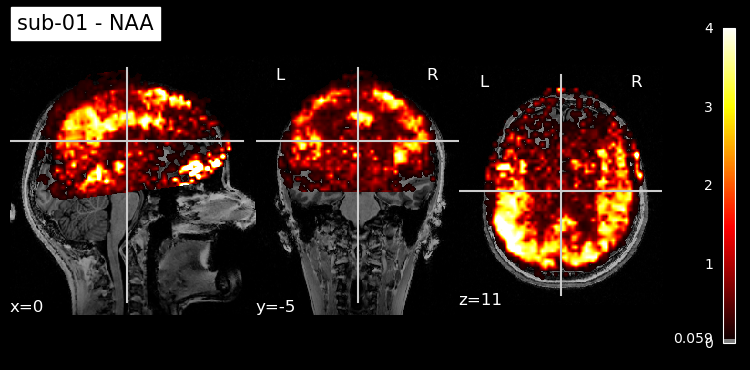

  Brain coverage: 18.6%


In [3]:
METABOLITE = "NAA"   # change to any metabolite label (e.g. "Cr", "Glu", "GABA")
match = [f for f in mrs_files if f"desc-{METABOLITE}_" in f]
if not match:
    print(f"No file found for metabolite '{METABOLITE}'")
else:
    print(f"Showing: {match[0]}")
    plot_single_overlay(match[0], T1W_PATH, MRS_DIR, subj=SUBJ)


## 3 – Coverage check: do the MRSI maps cover the whole brain?

Overlay several metabolite maps on the T1w in a single figure  so we can directly compare spatial coverage across metabolites.

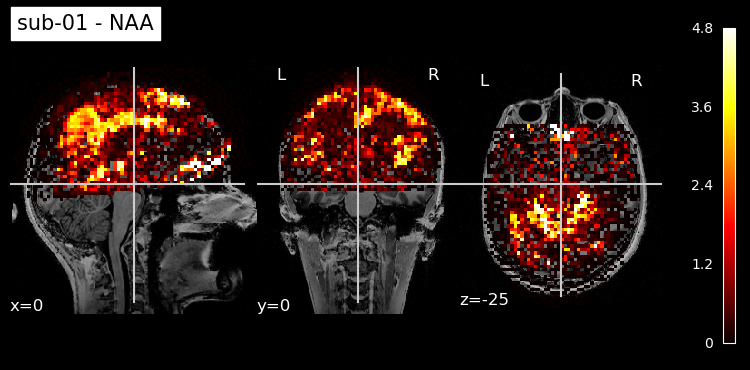

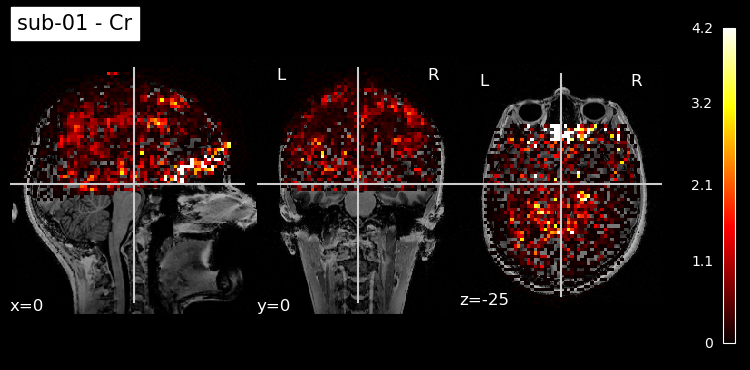

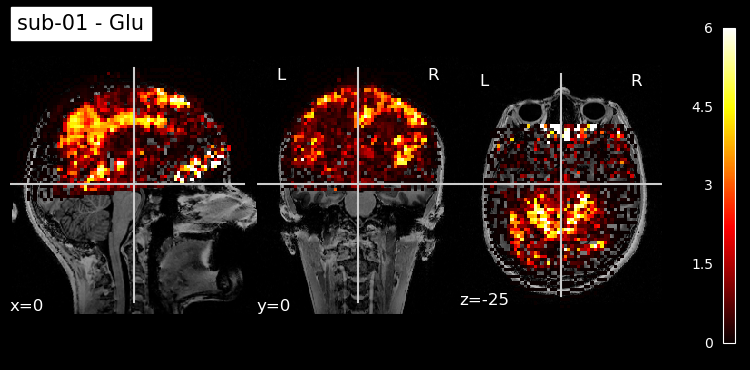

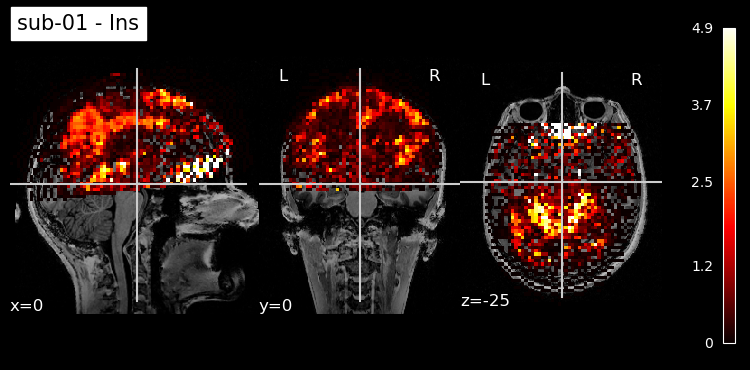

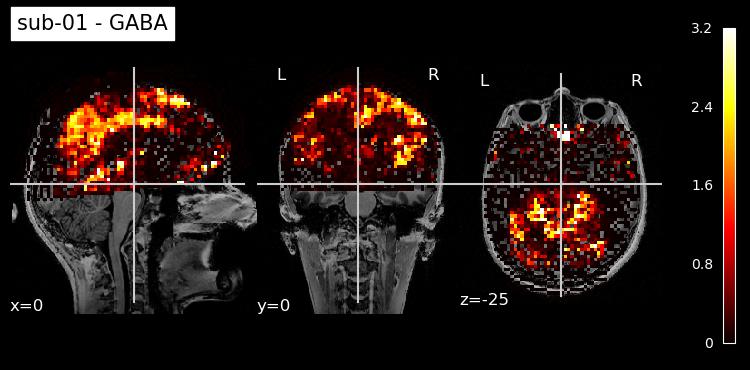

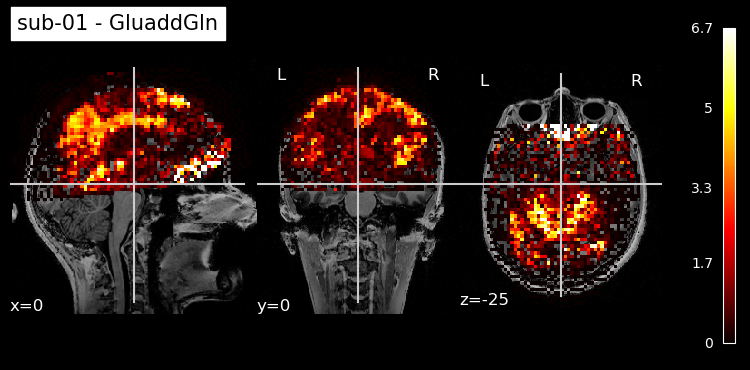

In [4]:
COVERAGE_MAPS = [
    f"{SUBJ}_{SES}_acq-OrigRes_desc-NAA_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Cr_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Glu_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Ins_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-GABA_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-GluaddGln_mrsi.nii.gz",
]
plot_coverage_grid(COVERAGE_MAPS, MRS_DIR, T1W_PATH, subj=SUBJ)


## 4  Native MRSI-space coverage 

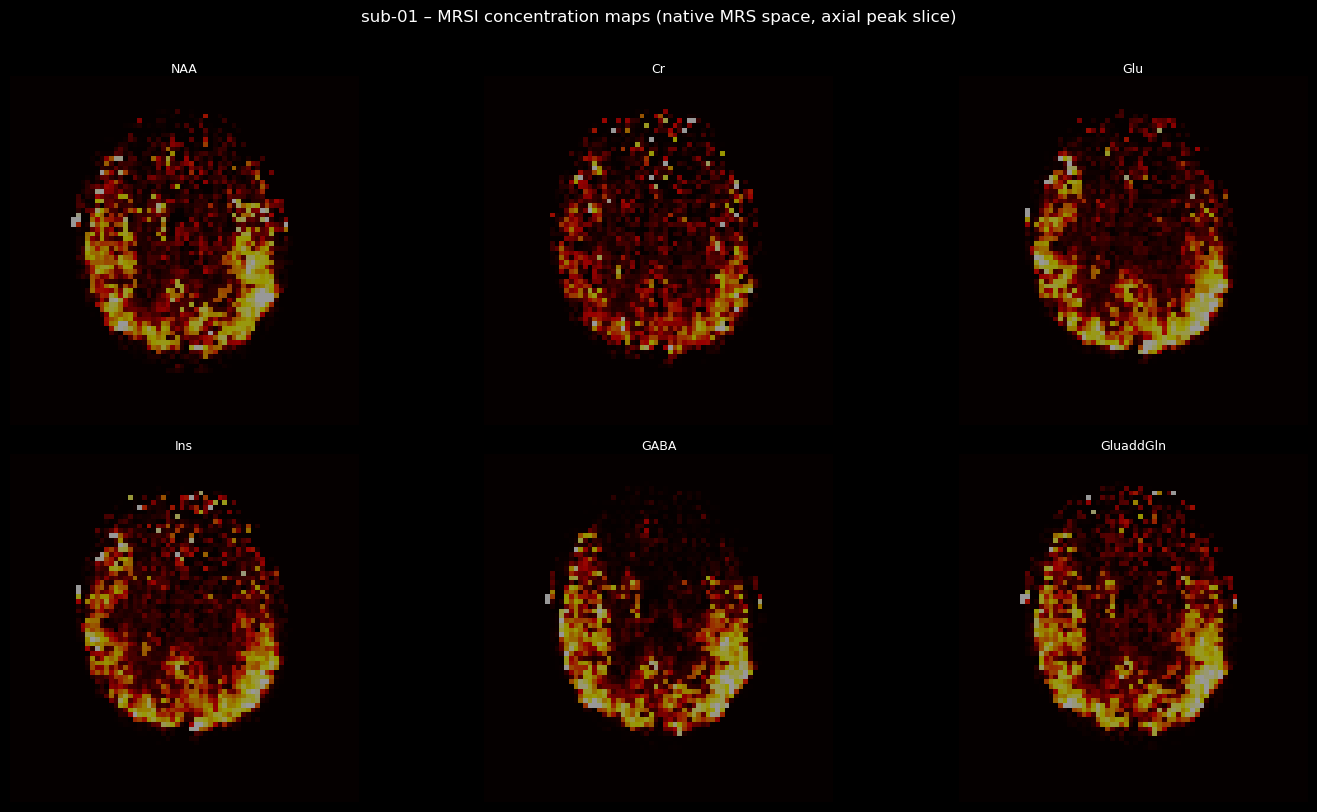

In [5]:
# one panel per metabolite, peak axial slice, normalised individually.
MOSAIC_MAPS = [
    f"{SUBJ}_{SES}_acq-OrigRes_desc-NAA_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Cr_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Glu_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Ins_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-GABA_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-GluaddGln_mrsi.nii.gz",
]
plot_mrsi_mosaic(MOSAIC_MAPS, MRS_DIR, subj=SUBJ, cmap="hot", cols=3)


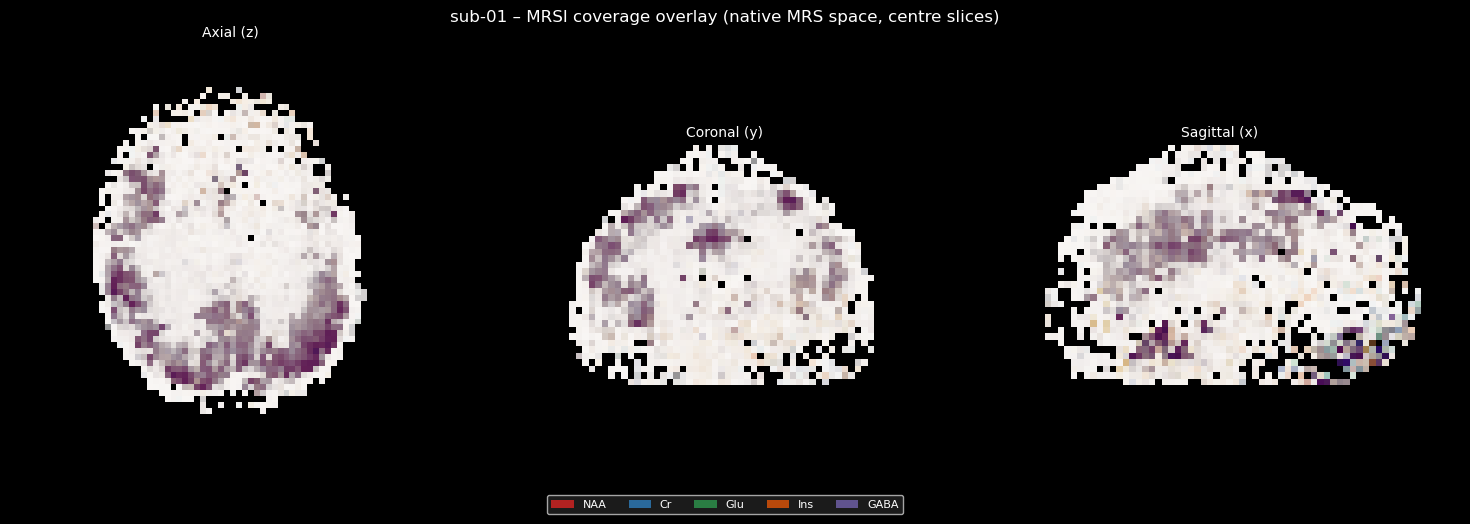

In [6]:
# Combined overlay: all maps on the same 3 views, each in its own colour.
COMBINED_MAPS = [
    f"{SUBJ}_{SES}_acq-OrigRes_desc-NAA_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Cr_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Glu_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Ins_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-GABA_mrsi.nii.gz",
]
plot_mrsi_combined(COMBINED_MAPS, MRS_DIR, subj=SUBJ, alpha=0.6)


## 5 – Support mask: pure binary spatial footprint

Binary mask of where signal exists, overlaid on the T1w.


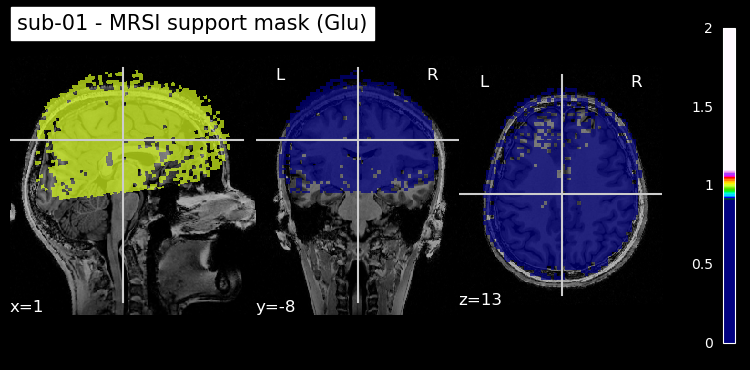

  Brain coverage: 14.1%


0.1414142215021152

In [7]:
plot_support_mask(
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Glu_mrsi.nii.gz",
    T1W_PATH, MRS_DIR, subj=SUBJ,
)

## 6 – Interactive multi-metabolite brain-coverage viewer

Use the checkboxes to pick any combination of metabolites.  
The selected maps are summed and overlaid on the T1w UNI-DEN background so you can compare spatial coverage at a glance.


In [8]:
from IPython.display import display
display(build_coverage_widget(MRS_DIR, subj=SUBJ))

## 7 – Sum of all metabolite maps (native MRS space)

`sum_img` is the voxel-wise sum of all `acq-OrigRes` concentration maps for `sub-01`, saved as a NIfTI and loaded by `main.py`.  
The mosaic below shows all 3 orthogonal centre-slice views.  
To regenerate the file for all subjects run `save_metabolite_sum(BIDS_DIR, ses=SES, overwrite=True)`.


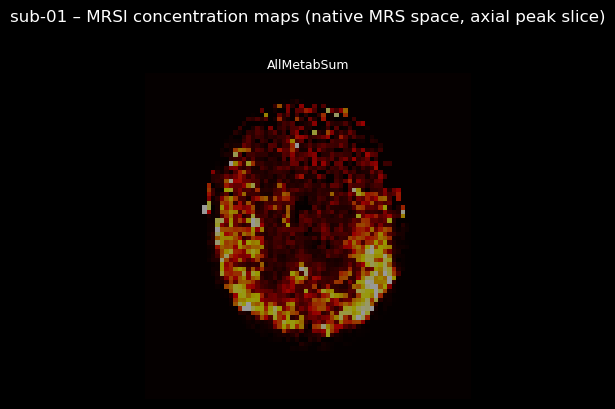

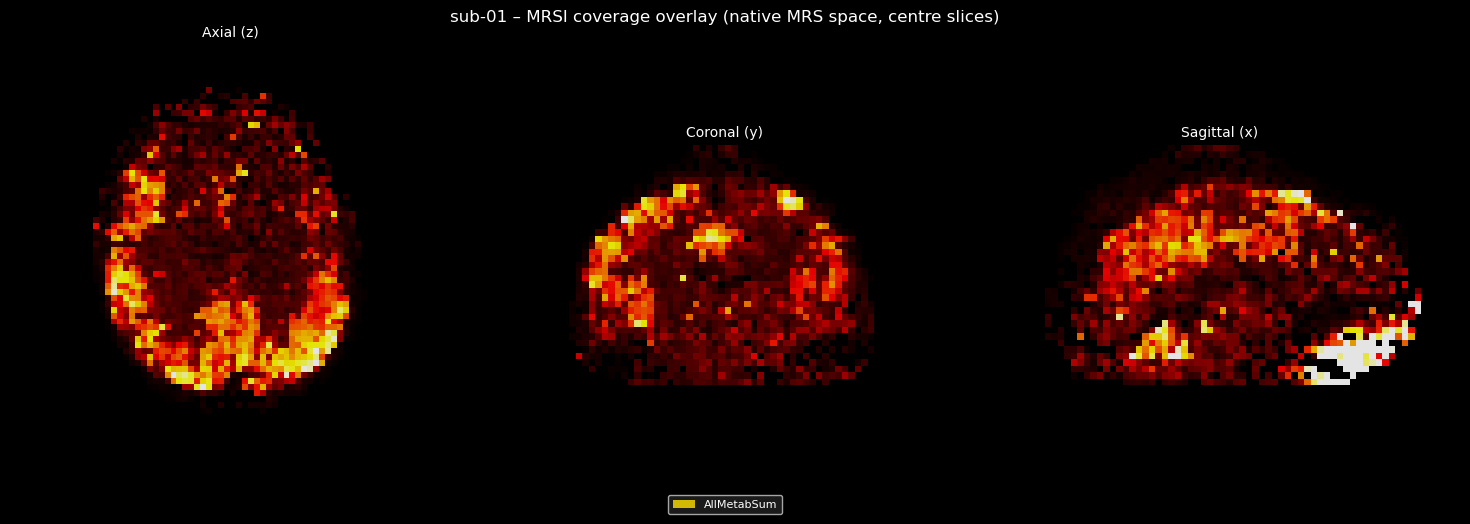

In [9]:
# visualise the all metabolite sum in native MRS space (3 orthogonal views)

plot_mrsi_mosaic([SUM_NAME], MRS_DIR, subj=SUBJ, cmap="hot", cols=1)

# visualise all 3 orthogonal centre slices side by side
plot_mrsi_combined([SUM_NAME], MRS_DIR, subj=SUBJ, cmaps=["hot"], alpha=0.9)


## 8 – Downsampled T1w at MRSI resolution

The T1w UNI-DEN image is resampled to the exact voxel grid of the MRSI concentration maps and saved as  
`anat/<subj>_<ses>_acq-MRSIres_T1w.nii.gz` for every subject that has an `anat/` folder.

The panel below shows (per row):
1. Downsampled T1w – axial, coronal, sagittal centre slices  
2. An MRSI concentration map at the same grid  
3. Their overlay (T1w grey + MRSI colour)


=== Downsampled T1w ===
T1w @ MRS res  (sub-01_ses-01_acq-MRSIres_T1w.nii.gz)
  shape      : (74, 74, 37)
  voxel size : [2.973 2.973 2.973] mm
  dtype      : float32

MRS ref        (sub-01_ses-01_acq-OrigRes_desc-2HG_mrsi.nii.gz)
  shape      : (74, 74, 37)
  voxel size : [2.973 2.973 2.973] mm
  dtype      : float32



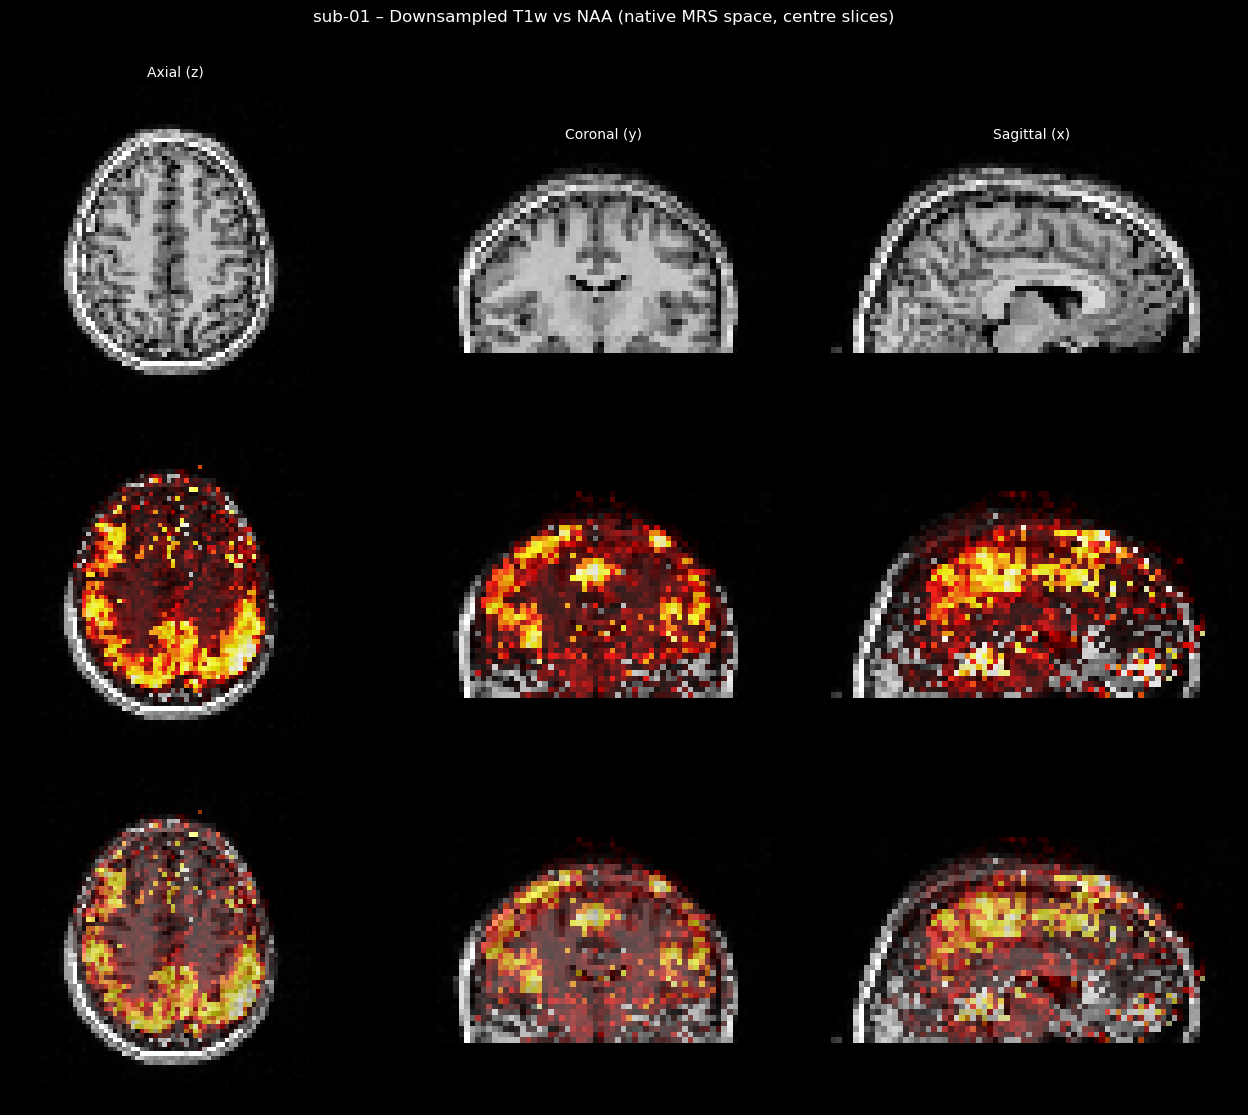

In [10]:

print("=== Downsampled T1w ===")
img_info(t1w_ds_img, f"T1w @ MRS res  ({T1W_DS_NAME})")
img_info(mrs_example, f"MRS ref        ({mrs_files[0]})")

# pick NAA as the representative metabolite for the overlay comparison
_ref_metab = f"{SUBJ}_{SES}_acq-OrigRes_desc-NAA_mrsi.nii.gz"
import nibabel as nib, os
_mrs_img = nib.load(os.path.join(MRS_DIR, _ref_metab))

plot_t1w_mrs_comparison(
    t1w_ds_img,
    _mrs_img,
    subj=SUBJ,
    mrs_label="NAA",
    )


## 9 – Best-SNR metabolite map

All `acq-OrigRes` concentration maps are ranked by their mean VoxelSNR**  the scanner derived per voxel SNR map (`desc-VoxelSNR_mrsi`) averaged over the support mask of each metabolite.

The bar chart shows mean and median SNR alongside spatial coverage (number of valid voxels).  
The best-ranked map is then displayed as a mosaic (peak axial slice per map) and as a combined ortho overlay.


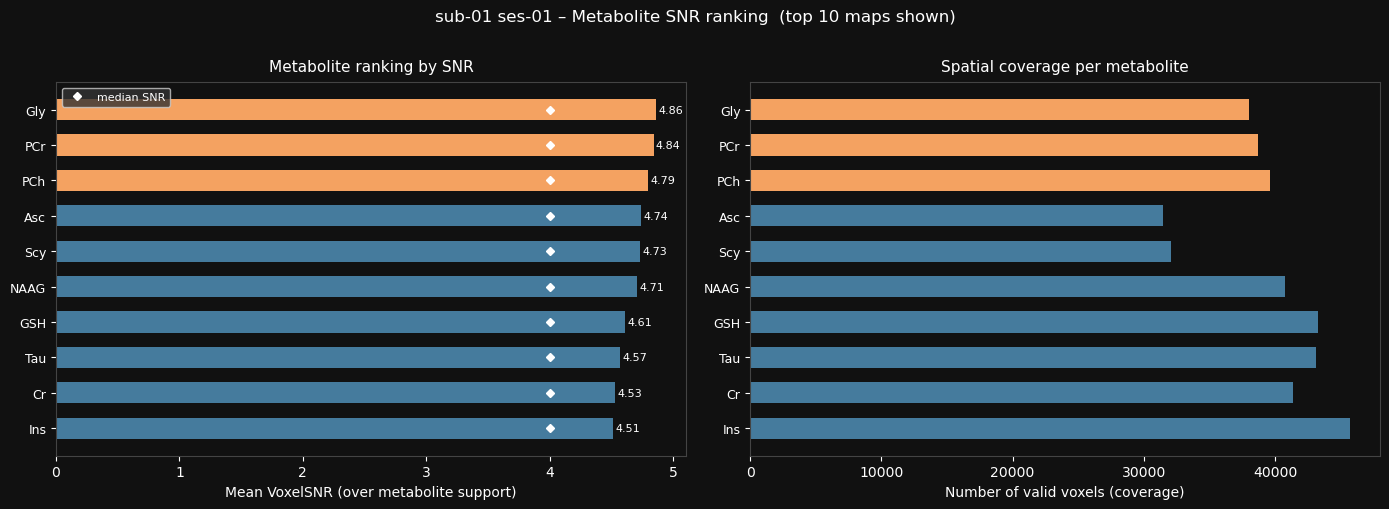


Top-3 metabolites by mean VoxelSNR:
  # 1  Gly                        mean_SNR=4.86  median_SNR=4.00  n_voxels=38,015  CV=9.187
  # 2  PCr                        mean_SNR=4.84  median_SNR=4.00  n_voxels=38,708  CV=4.719
  # 3  PCh                        mean_SNR=4.79  median_SNR=4.00  n_voxels=39,631  CV=2.344


In [11]:
# rank all metabolites by SNR using the scanner-provided VoxelSNR map
snr_records = rank_metabolites_by_snr(MRS_DIR, subj=SUBJ, ses=SES)

# bar chart: mean/median SNR + coverage for the top-20 maps
plot_snr_ranking(snr_records, top_n=10, highlight_best=3)


Best SNR metabolite: Gly  (mean_SNR=4.86)


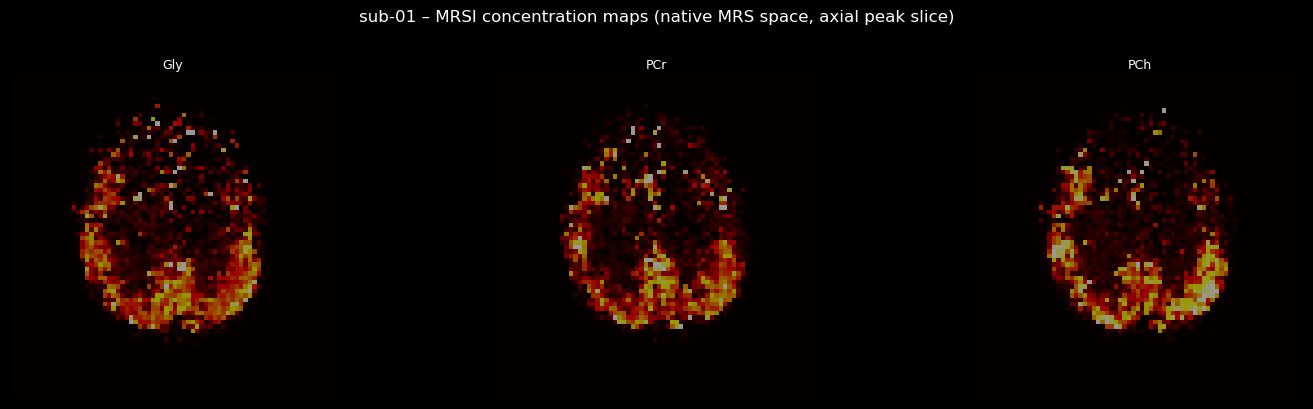

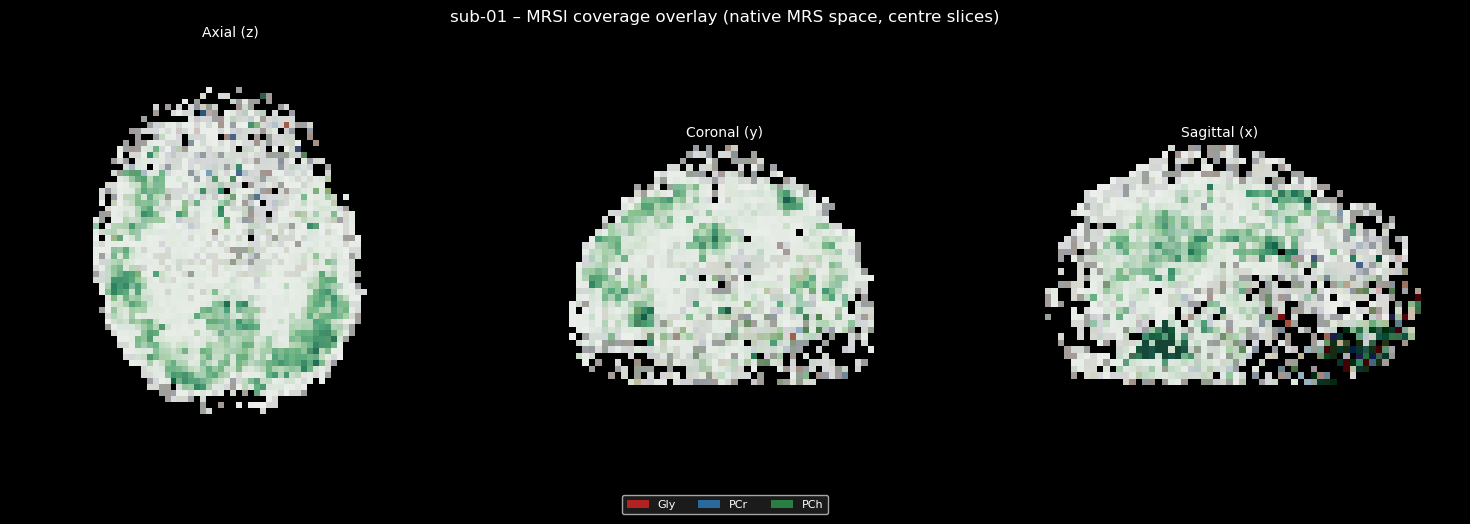

In [12]:
# visualise the best-SNR map and the top-3 together
best = snr_records[0]
top3 = [r["filename"] for r in snr_records[:3]]

print(f"Best SNR metabolite: {best['metabolite']}  (mean_SNR={best['mean_snr']:.2f})")

# mosaic: peak axial slice for each of the top-3 maps
plot_mrsi_mosaic(top3, MRS_DIR, subj=SUBJ, cmap="hot", cols=3)

# combined ortho overlay of the top-3, each in its own colour
plot_mrsi_combined(top3, MRS_DIR, subj=SUBJ, alpha=0.65)


## 10 – Water mask: raw vs hole-filled comparison

Side-by-side visual comparison of:
- **Raw mask** — binary threshold on the WaterSignal image (`value > 0`)
- **Filled mask** — same mask after `fill_mask_holes` (scipy `binary_fill_holes`)
- **Hole map** — voxels that were missing in the raw mask but recovered by filling


In [13]:
plot_water_mask_comparison(water_img, mask, subj=SUBJ, ses=SES)


NameError: name '_water' is not defined

## 11 – T1w/MRSI registration: before vs after

The downsampled T1w is masked with the filled water mask and then rigidly registered to the best-SNR MRSI map using ANTsPy. Because both images come from the same subject and session, a rigid transform is sufficient.

Left column: unregistered downsampled T1w overlaid on MRSI.  
Right column: registered T1w overlaid on the same MRSI map.


Best-SNR metabolite used as registration target: Gly


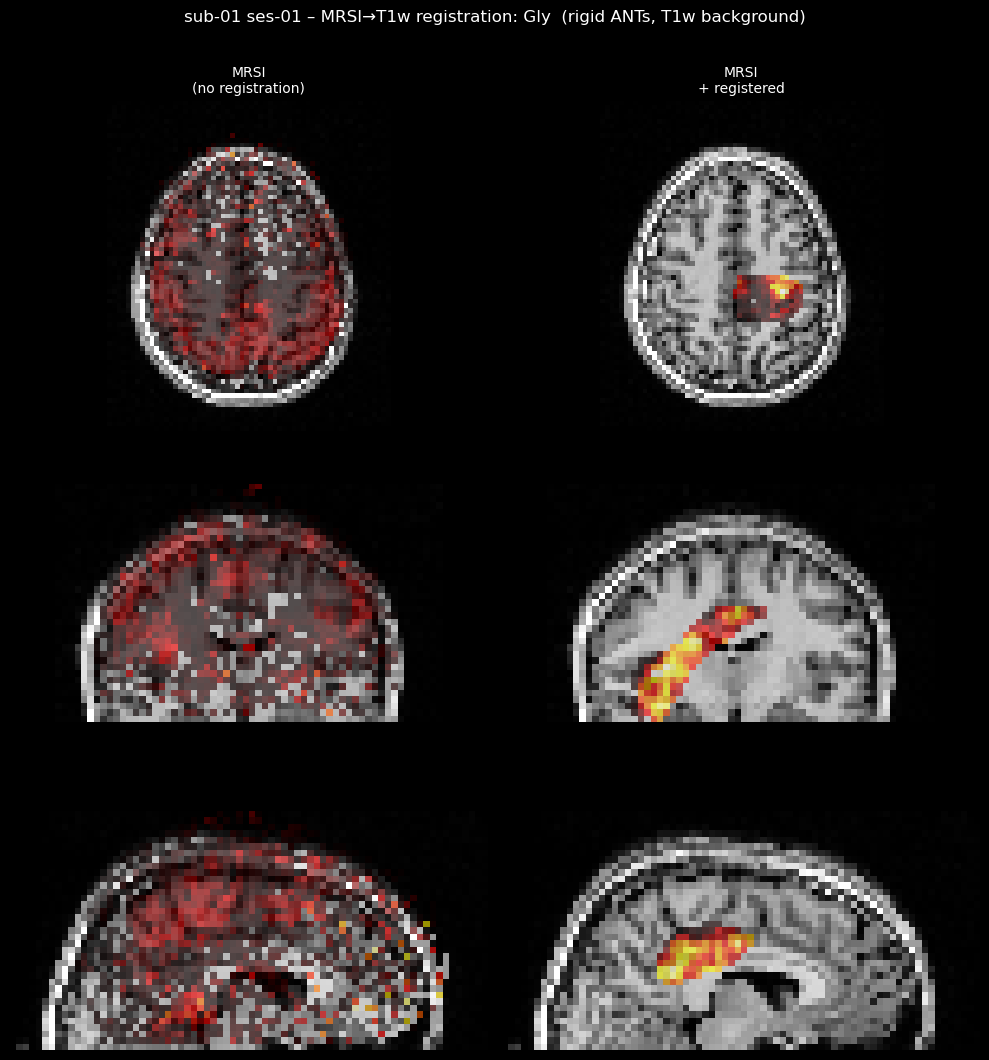

In [ ]:
print(f"Best-SNR metabolite used as registration target: {best_mrsi_label}")
plot_registration_comparison(
    t1w_ds_img,
    best_mrsi_img,
    mrsi_reg_ds_img,
    subj=SUBJ,
    ses=SES,
    mrsi_label=best_mrsi_label,
)


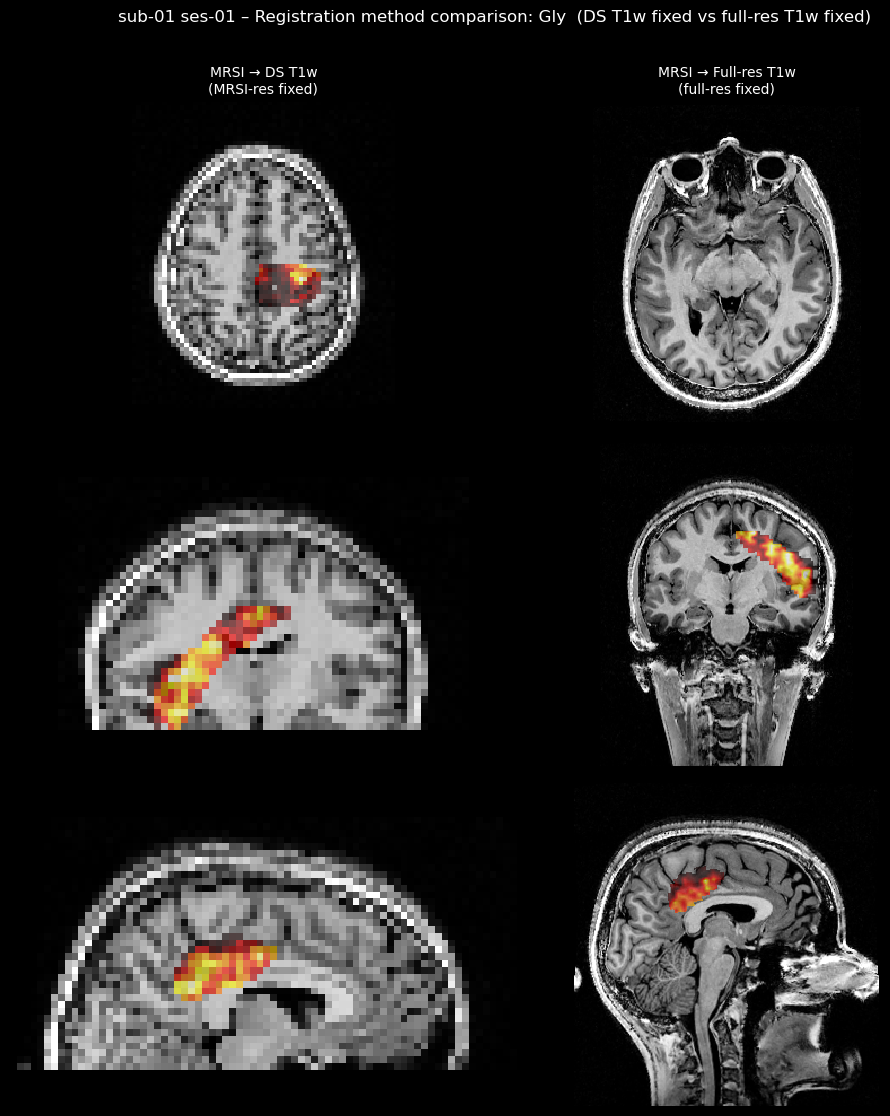

In [ ]:
# Compare the two registration strategies, both in T1w space:
#   Left  - MRSI registered to DS T1w (MRSI-res fixed)
#   Right - MRSI registered to full-resolution T1w (full-res fixed)
plot_registration_methods_comparison(
    t1w_ds_img,
    t1w_img,
    mrsi_reg_ds_img,
    mrsi_reg_fullres_img,
    subj=SUBJ,
    ses=SES,
    mrsi_label=best_mrsi_label,
)


## 12 – Registration target comparison: best-SNR metabolite vs metabolite sum

Two strategies for choosing the moving image to register to the downsampled T1w (rigid ANTs):

- Left  image = best-SNR metabolite map  
- Right image = voxel-wise sum of all metabolite maps



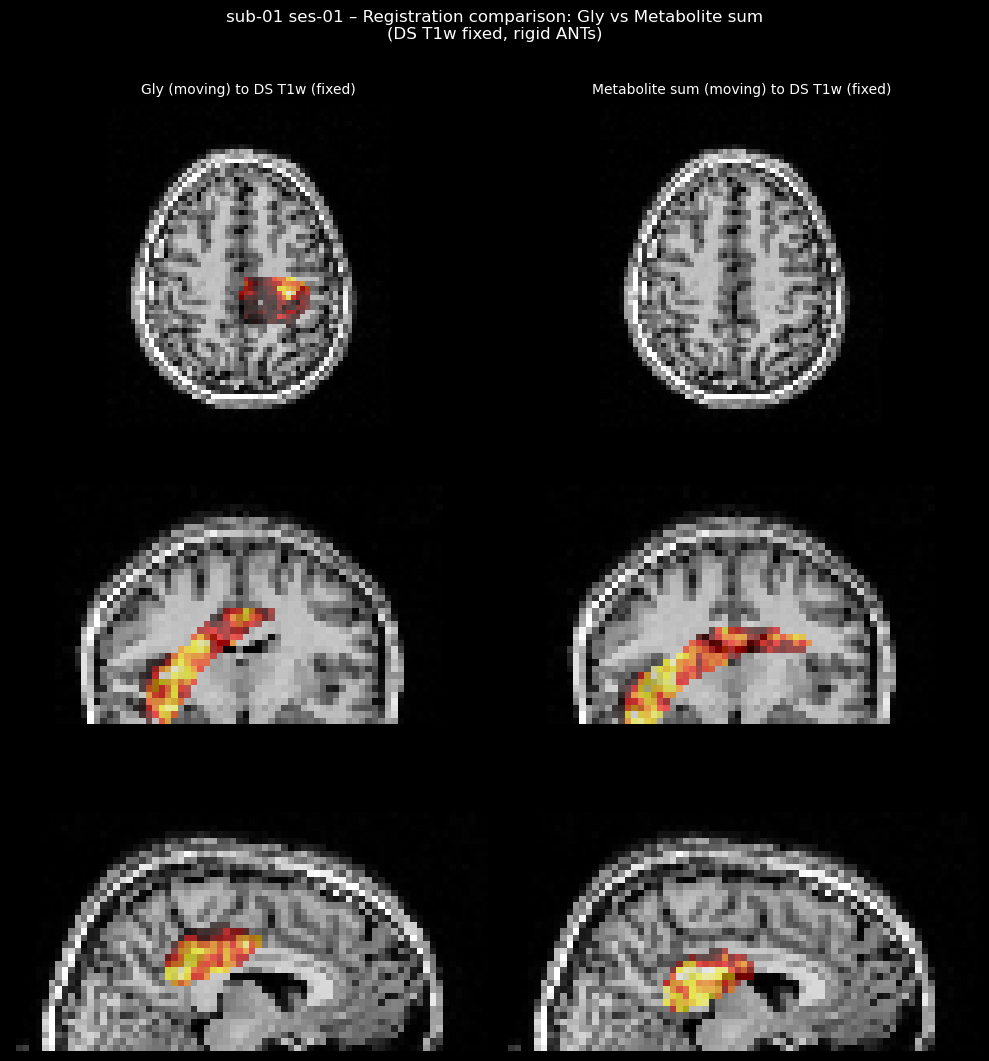

In [ ]:
plot_registration_target_comparison(
    t1w_ds_img,
    mrsi_reg_ds_img,
    mrsi_sum_reg_img,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=best_mrsi_label,
)


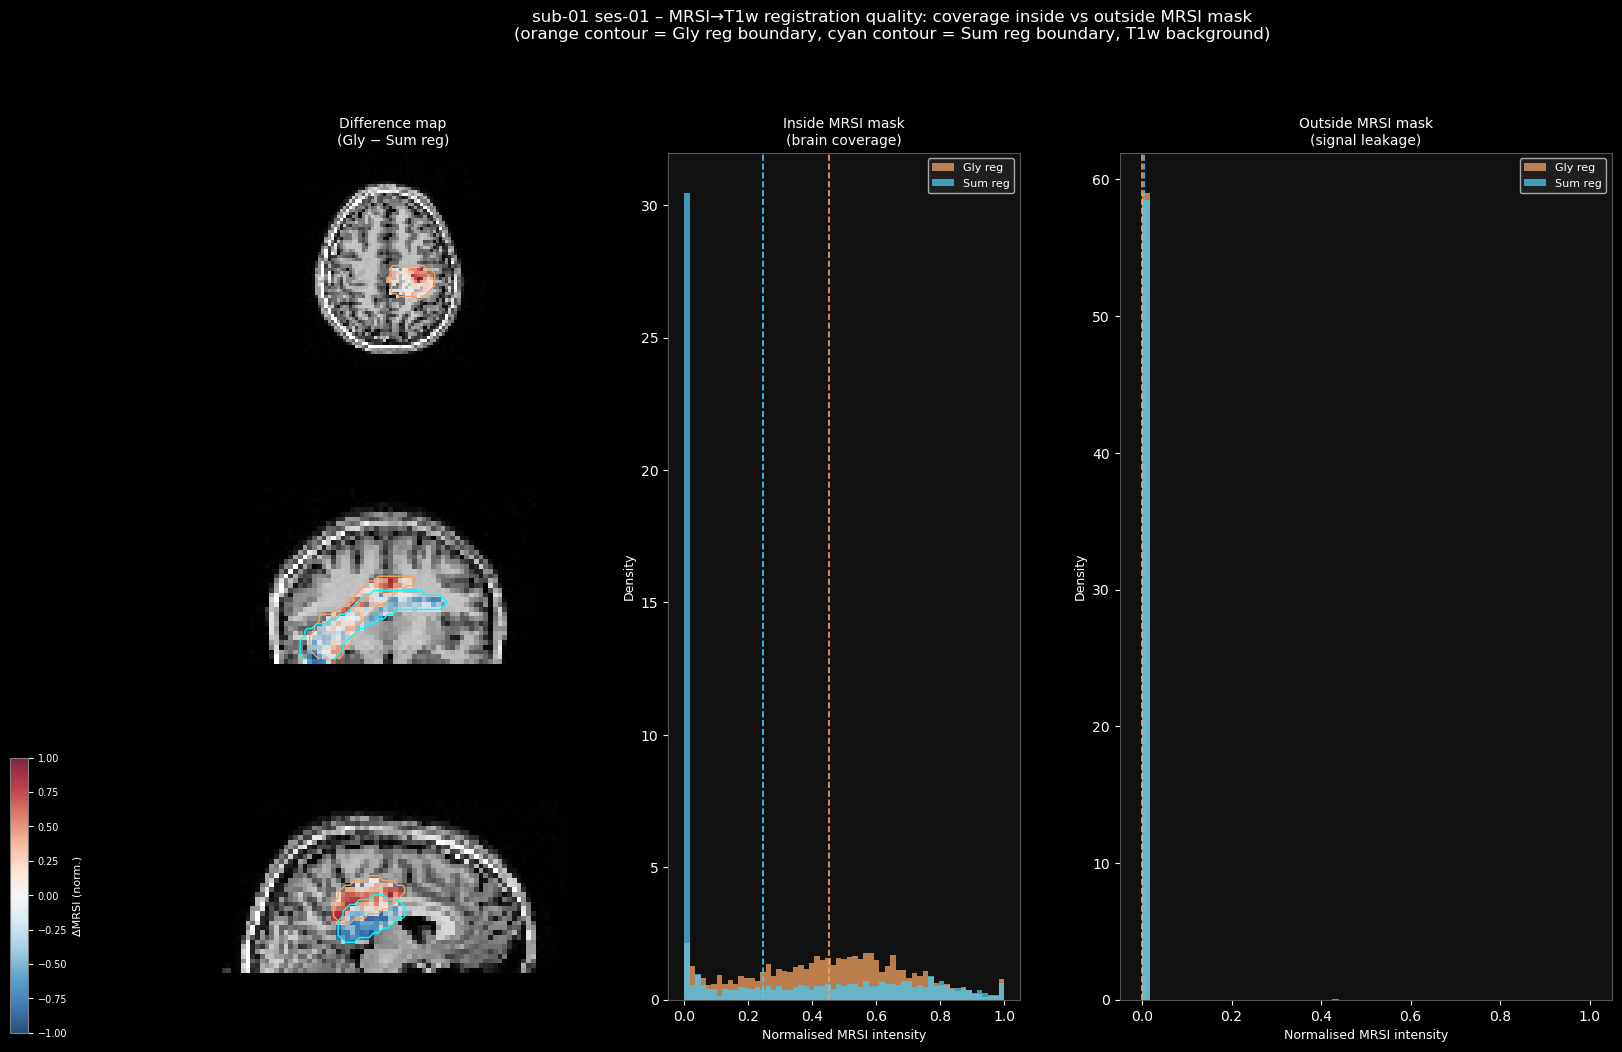

Metric                               Gly reg         Sum reg         Δ (a−b)
────────────────────────────────────────────────────────────────────────────
Mean MRSI in-mask                     0.4520          0.2457         +0.2063
Mean MRSI out-of-mask                 0.0000          0.0040         -0.0040
In/Out SNR ratio              452022671.6995         60.7996  +452022610.8999
% active voxels in-mask              92.6584         45.9739        +46.6844
% active voxels out                   0.0000          0.7955         -0.7955


In [ ]:
# Quantitative coverage comparison: in-mask vs out-of-mask MRSI intensity
# + signed difference map (best-SNR reg - sum reg) + metrics table
# Two contours show where each registration places the MRSI FOV boundary:
#   orange = best-SNR (Gly) registration,  cyan = sum registration
cov_metrics = compare_registration_coverage(
    t1w_ds_img,
    mask,
    best_mrsi_img,
    mrsi_reg_ds_img,
    mrsi_sum_reg_img,
    reg1_transforms,
    reg3_transforms,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=best_mrsi_label,
)


## 13 – Metabolite sum: independent registration vs best-SNR transform reuse

Two ways to bring the gly map into DS T1w space:
- Left independent registration: the gly image is used as the moving image and ANTs solves a new rigid transform optimised specifically for it.
- Right transform reuse: the rigid transform already solved for the sum image is applied directly to the sum, with no re optimisation.


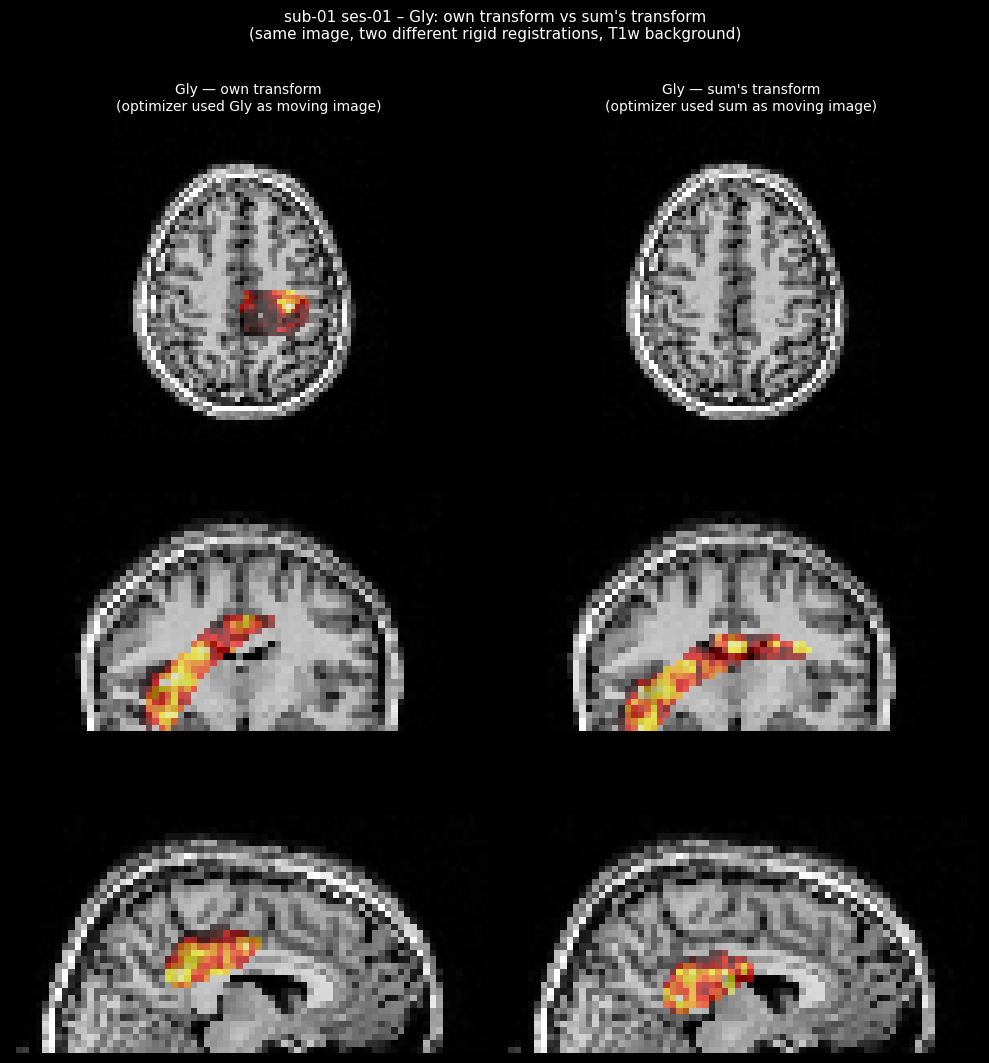

                                   mean in brain   CC with T1w
  ----------------------------------------------------------
  Gly — own transform                     0.0239        0.0797
  Gly — sum's transform                   0.0226        0.0712


In [ ]:
plot_sum_registration_comparison(
    t1w_ds_img,
    mrsi_reg_ds_img,
    mrsi_gly_via_sum_img,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=best_mrsi_label,
)

## 14 – Coverage-based vs SNR-based registration: three-way comparison

Three ways of placing the **Gly** map (best-SNR metabolite) and the **best-coverage** metabolite into DS T1w space, all compared side by side:

- **Left** — best-coverage metabolite (e.g. Ins) with its **own** rigid transform. Broader signal gives ANTs more overlap to lock onto.
- **Centre** — Gly with its **own** rigid transform (Reg 1): the optimal transform for Gly — used as the reference throughout.
- **Right** — Gly with the **metabolite sum’s transform** (Reg 3) applied directly, no re-optimisation. Shows the error introduced by using an aggregate map as the registration target.

The metrics table below each figure reports mean in-brain intensity and correlation with the T1w for each strategy.

Best-coverage metabolite : MM14addLip13aaddLip13baddMM12  (49036 voxels)
Best-SNR (Gly)           : Gly  (38015 voxels)


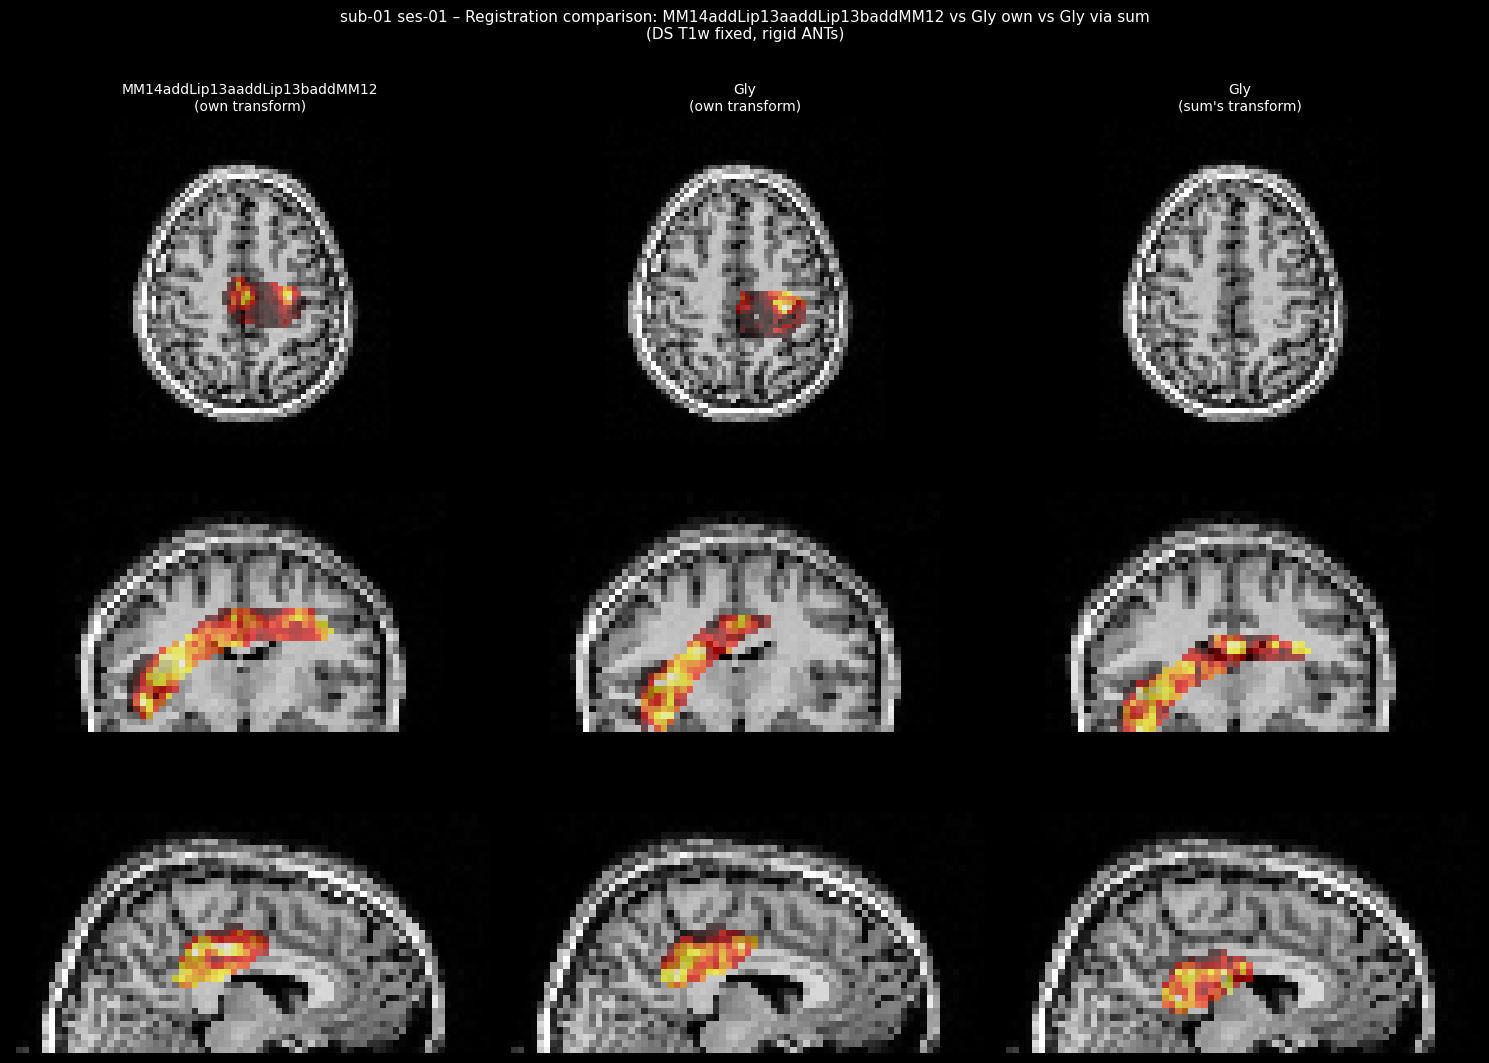


  Strategy                               Mean in brain   CC with T1w
  ------------------------------------------------------------------
  MM14addLip13aaddLip13baddMM12 — own transform          0.0260        0.0877
  Gly — own transform                           0.0239        0.0797
  Gly — sum's transform                         0.0226        0.0712


In [ ]:
print(f"Best-coverage metabolite : {best_cov_label}  ({coverage_records[0]['n_voxels']} voxels)")
print(f"Best-SNR (Gly)           : {best_mrsi_label}  ({snr_records[0]['n_voxels']} voxels)")

plot_coverage_registration_comparison(
    t1w_ds_img,
    mrsi_cov_reg_img,
    mrsi_reg_ds_img,
    mrsi_gly_via_sum_img,
    subj=SUBJ,
    ses=SES,
    cov_label=best_cov_label,
    gly_label=best_mrsi_label,
)


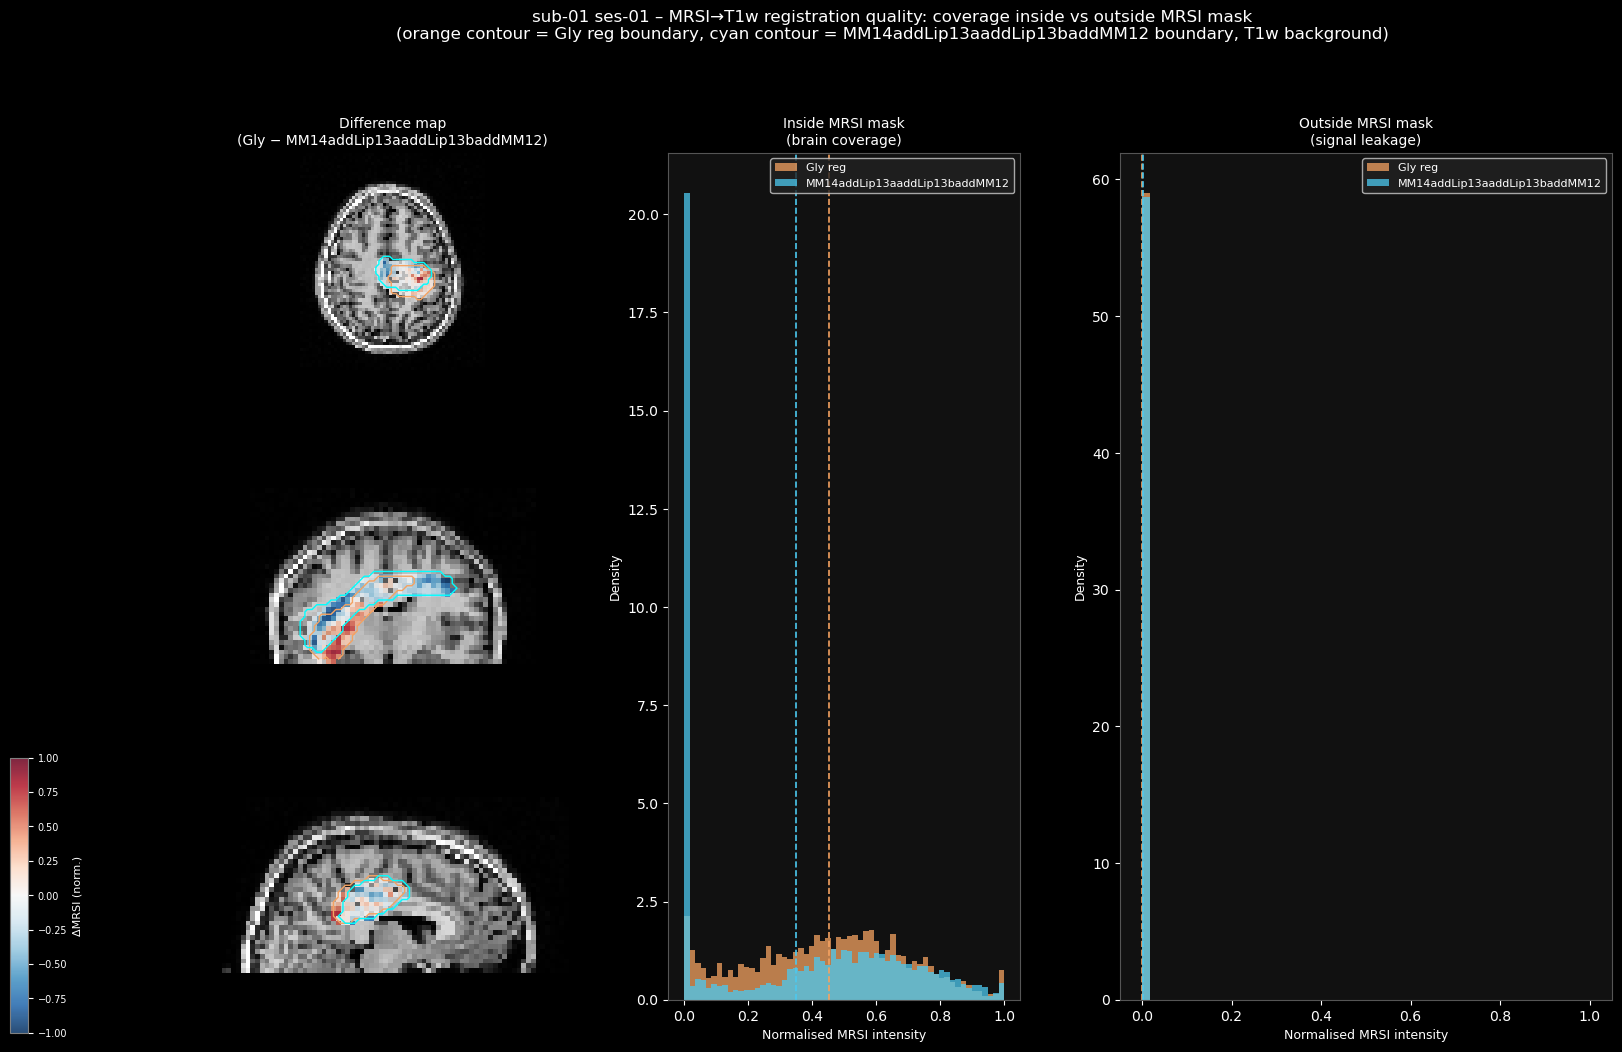

Metric                               Gly reg  MM14addLip13aaddLip13baddMM12         Δ (a−b)
───────────────────────────────────────────────────────────────────────────────────────────
Mean MRSI in-mask                     0.4520          0.3485         +0.1035
Mean MRSI out-of-mask                 0.0000          0.0024         -0.0024
In/Out SNR ratio              452022671.6995        146.3003  +452022525.3992
% active voxels in-mask              92.6584         63.7063        +28.9520
% active voxels out                   0.0000          0.5095         -0.5095


{'best_snr': {'mean_in': 0.4520226716995239,
  'mean_out': 0.0,
  'snr_ratio': 452022671.6995239,
  'pct_active_in': 92.65837773830668,
  'pct_active_out': 0.0},
 'sum': {'mean_in': 0.34851738810539246,
  'mean_out': 0.0023822046350687742,
  'snr_ratio': 146.30029539634214,
  'pct_active_in': 63.70633510953226,
  'pct_active_out': 0.5094511980886797}}

In [ ]:
compare_registration_coverage(
    t1w_ds_img,
    mask,
    best_mrsi_img,
    mrsi_reg_ds_img,
    mrsi_cov_reg_img,
    reg1_transforms,
    reg6_transforms,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=best_mrsi_label,
    sum_label=best_cov_label,
)


## 15 – Inverse registration: T1w → MRSI space

Register the **downsampled T1w** (moving) to each MRSI map (fixed), placing anatomy
into the native MRS coordinate frame — the inverse of all previous registrations.

Three columns (MRSI overlay on registered T1w background):
- **Left** – T1w → metabolite-sum space (sum-driven transform).
- **Centre** – T1w → Gly space (Gly-own transform).
- **Right** – T1w into Gly space by reusing the sum transform directly.


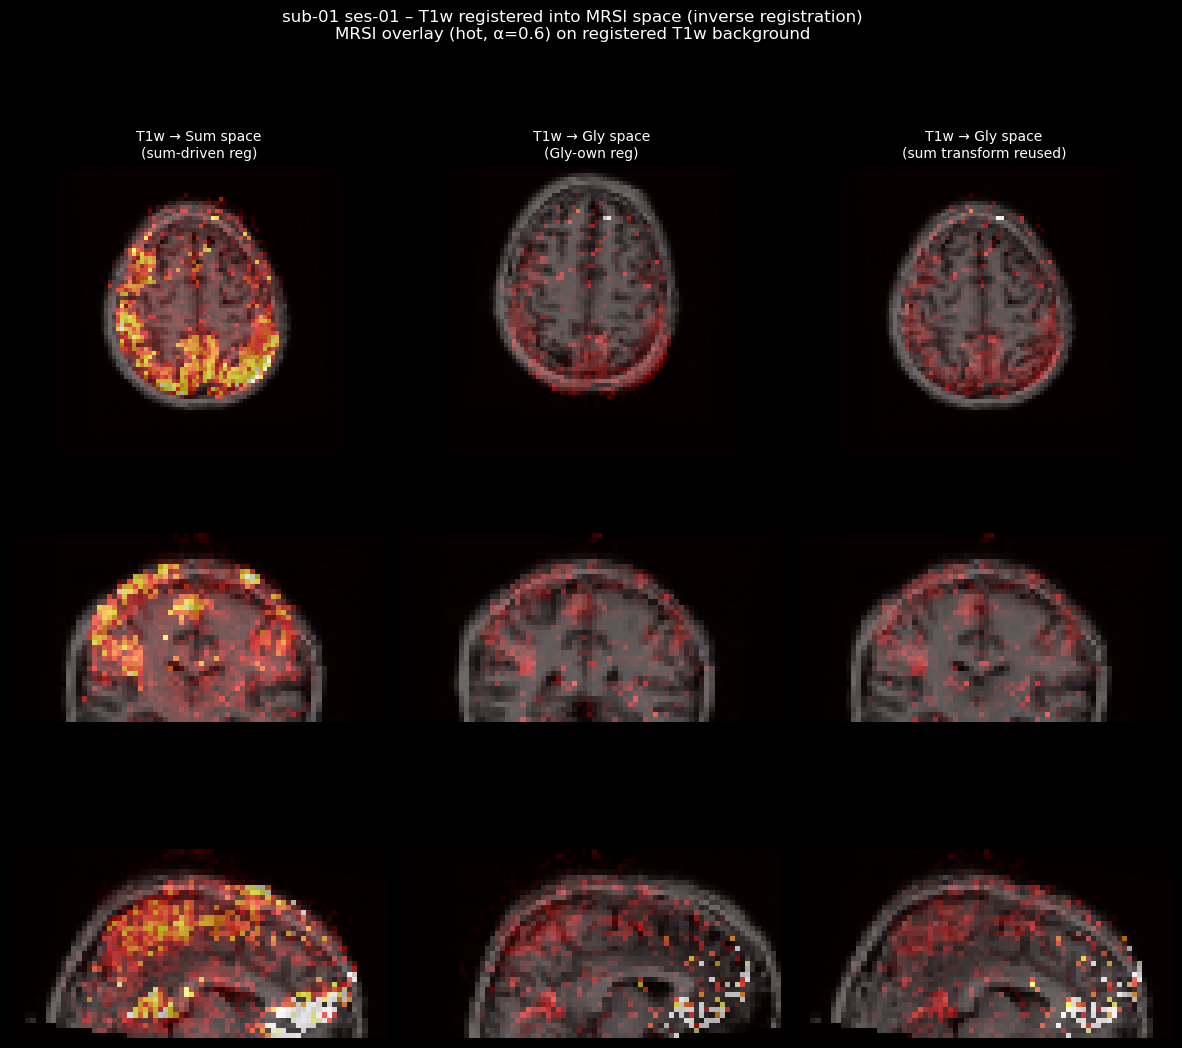

In [ ]:
plot_inverse_registration_panels(
    mrsi_sum_img=sum_img,
    mrsi_gly_img=best_mrsi_img,
    t1w_via_sum_img=t1w_in_sum_img,
    t1w_via_gly_img=t1w_in_gly_img,
    t1w_via_sum_in_gly_img=t1w_via_sum_in_gly_img,
    subj=SUBJ,
    ses=SES,
    sum_label="Sum",
    gly_label=best_mrsi_label,
)


## 16 – Weighted inverse registration: water signal as mask

Supply the water signal image  as `mask` (fixed-image mask) in ANTs.

Three comparisons on the MRSI background:
- Left  T1w via no weighting mask inverse registration (Reg 8).
- Right  T1w via water weighted inverse registration (Reg 10).

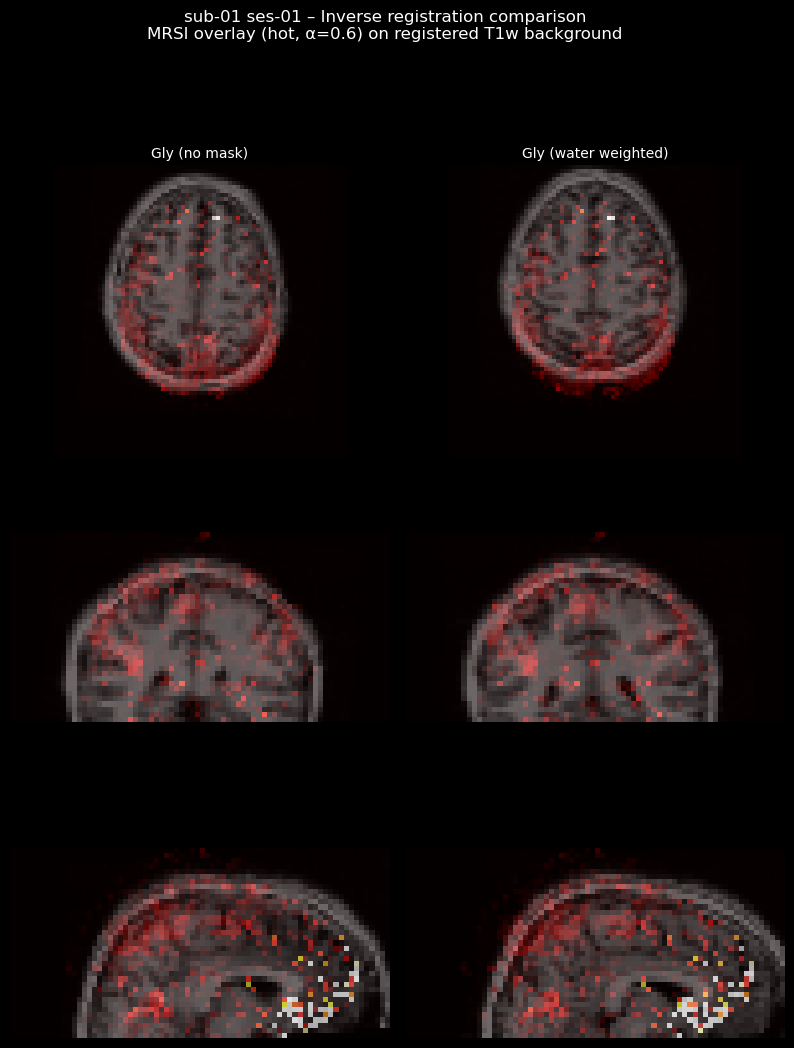

In [ ]:
compare_inverse_registration_pair(
    best_mrsi_img,
    t1w_in_gly_img,
    t1w_in_gly_w_img,
    subj=SUBJ,
    ses=SES,
    label_left=f"{best_mrsi_label} (no mask)",
    label_right=f"{best_mrsi_label} (water weighted)",
)

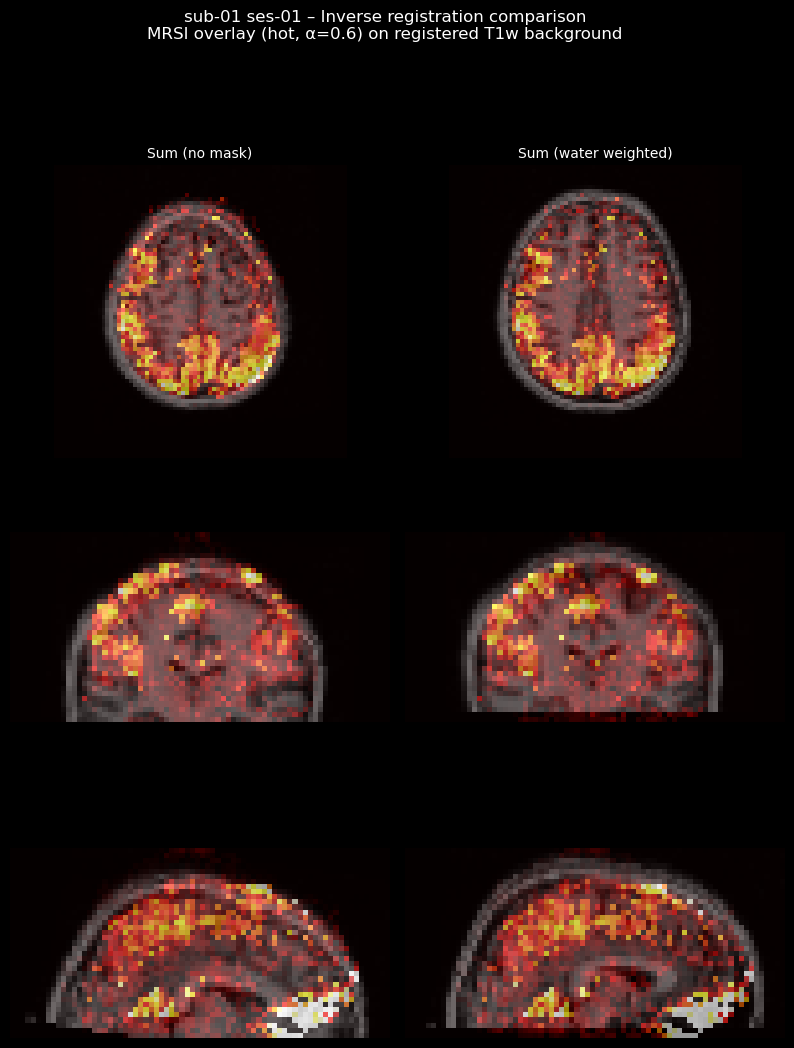

In [ ]:
compare_inverse_registration_pair(
    sum_img,
    t1w_in_sum_img,
    t1w_in_sum_w_img,
    subj=SUBJ,
    ses=SES,
    label_left="Sum (no mask)",
    label_right="Sum (water weighted)",
)

## 17 – Water map alignment: naive vs Reg-11 reused vs Reg-18 direct

Three-way comparison on the **water signal map** background (all T1w images in water-signal coordinate space):

| Column | Method | Description |
|--------|--------|-------------|
| Left | Naive | Full-res T1w directly resampled to water grid — no registration |
| Middle | Reg-11 reused | Reg-11 sum water-weighted transform (`inv_sum_w_transforms`) applied to T1w DS, resampled to water space — no re-optimisation |
| Right | Reg-18 | T1w DS directly registered to water signal map (ANTs CLI rigid + water mask) |


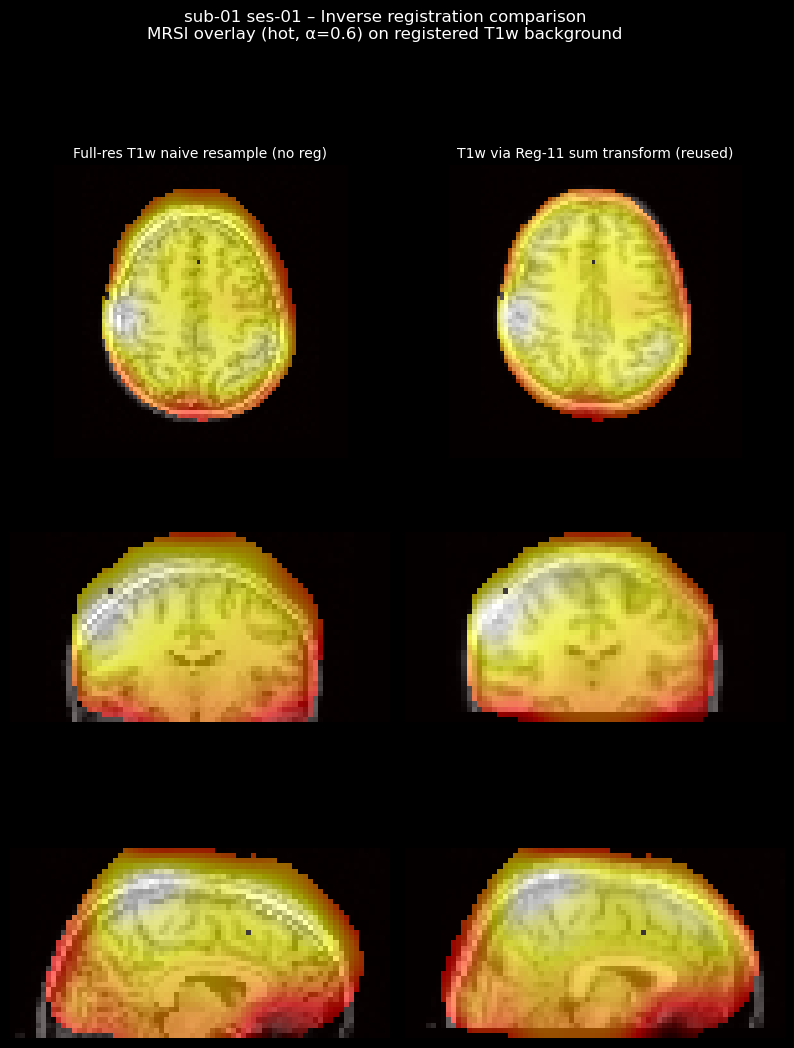

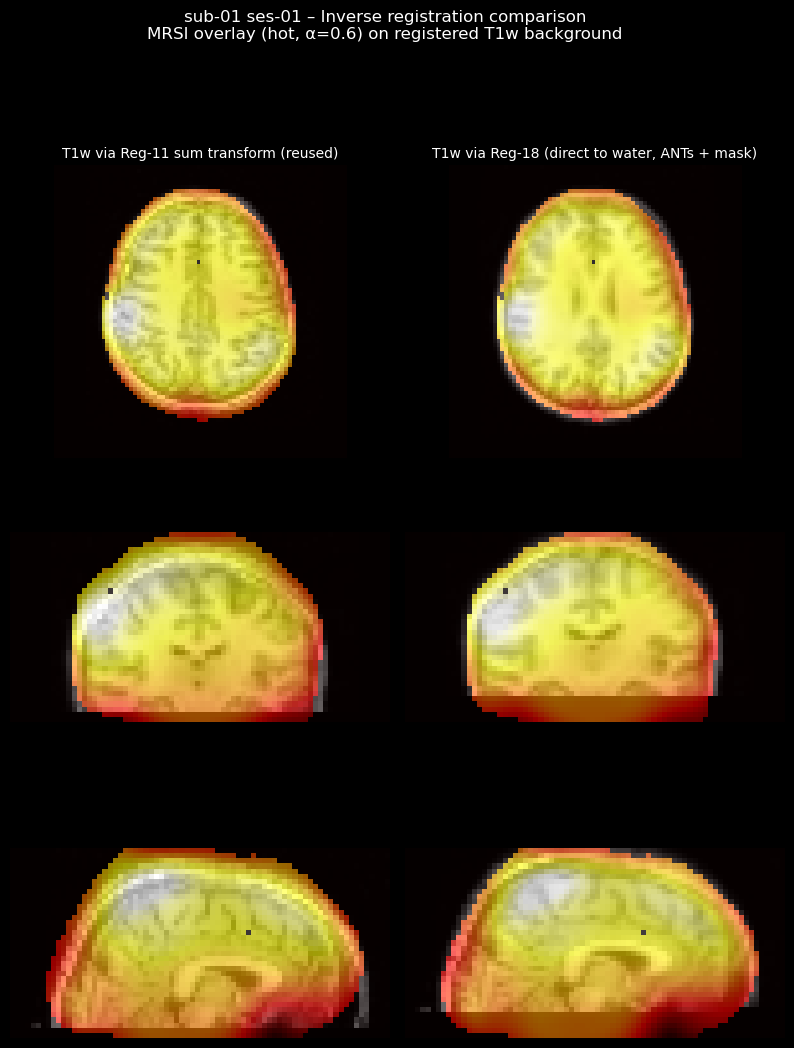

In [ ]:
# Left vs middle: naive resample vs Reg-11 sum transform reused
compare_inverse_registration_pair(
    water_img,
    t1w_ds_img,
    t1w_in_water_via17_img,
    subj=SUBJ,
    ses=SES,
    label_left="Full-res T1w naive resample (no reg)",
    label_right="T1w via Reg-11 sum transform (reused)",
)

# Middle vs right: Reg-11 reused vs Reg-18 direct
compare_inverse_registration_pair(
    water_img,
    t1w_in_water_via17_img,
    t1w_in_water_img,
    subj=SUBJ,
    ses=SES,
    label_left="T1w via Reg-11 sum transform (reused)",
    label_right="T1w via Reg-18 (direct to water, ANTs + mask)",
)


## 18 – Skull-stripped T1w registered to MRSI space

The downsampled T1w is first skull-stripped with **FSL BET** (`-f 0.3`), then
rigidly registered to each MRSI map.  Removing non-brain tissue focuses ANTs'
metric evaluation entirely on brain voxels, which often improves alignment.

Two comparisons on the MRSI background:
- **Left** – original (non-stripped) T1w registration (baseline).
- **Right** – skull-stripped T1w registration.

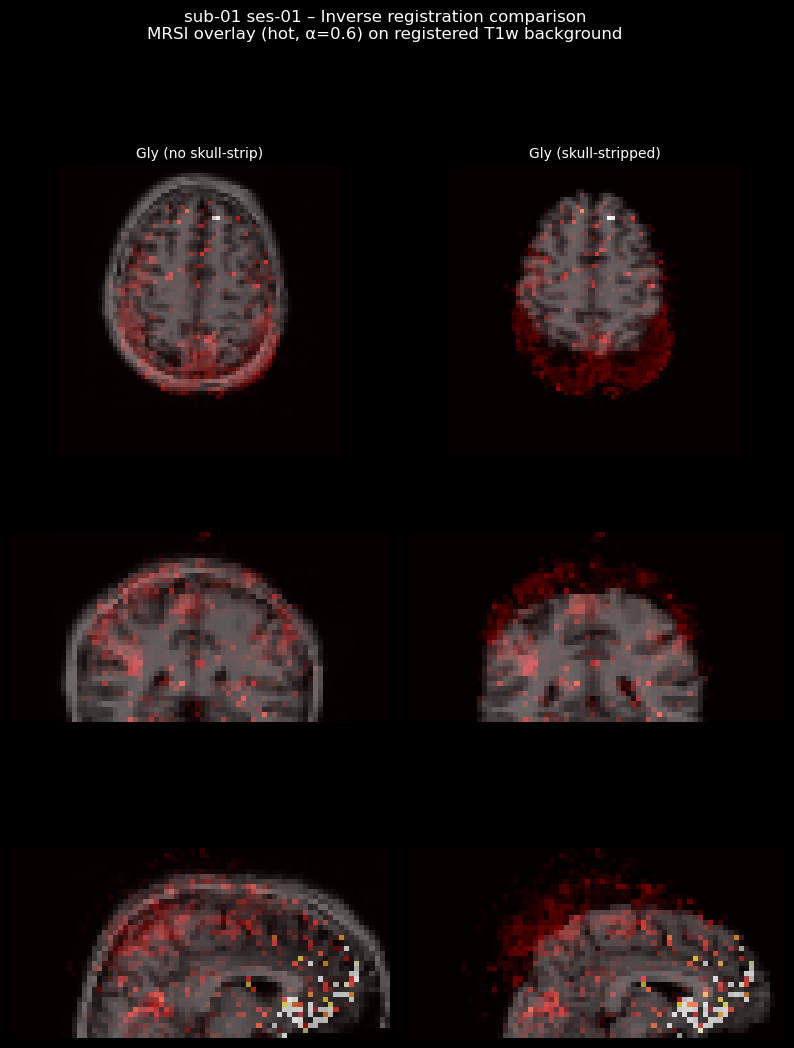

In [ ]:
# Gly: original vs skull-stripped
compare_inverse_registration_pair(
    best_mrsi_img,
    t1w_in_gly_img,
    t1w_brain_in_gly_img,
    subj=SUBJ,
    ses=SES,
    label_left=f"{best_mrsi_label} (no skull-strip)",
    label_right=f"{best_mrsi_label} (skull-stripped)",
)

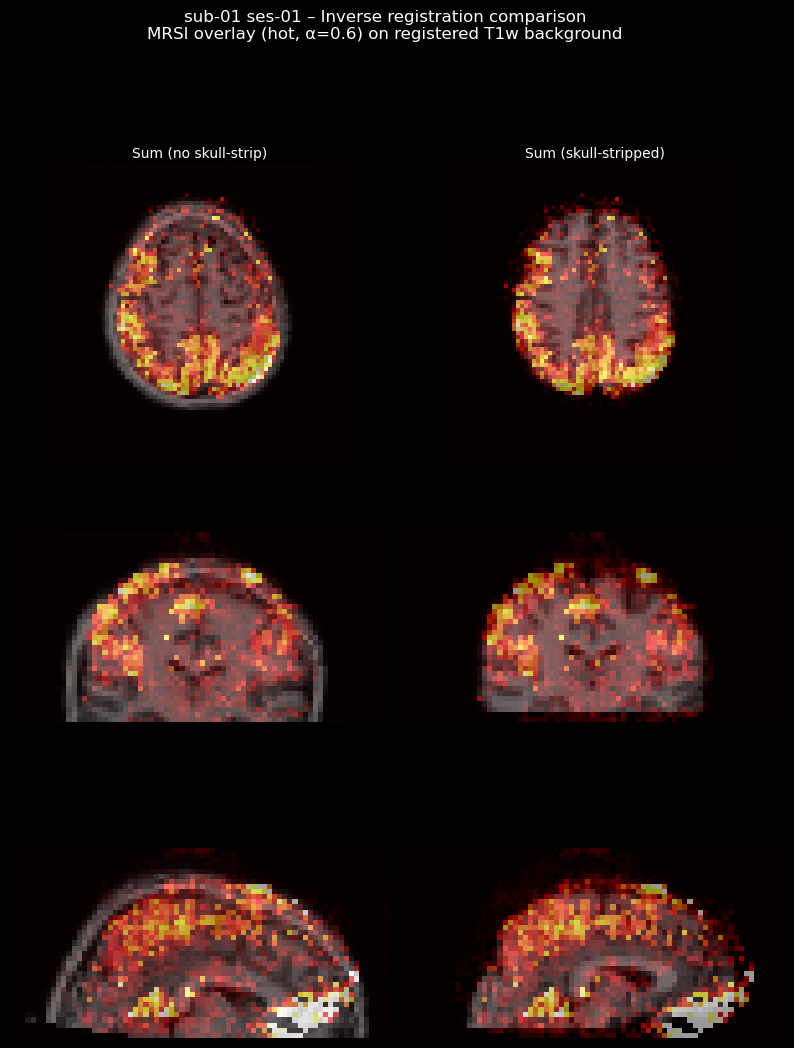

In [ ]:
# Sum: original vs skull-stripped
compare_inverse_registration_pair(
    sum_img,
    t1w_in_sum_img,
    t1w_brain_in_sum_img,
    subj=SUBJ,
    ses=SES,
    label_left="Sum (no skull-strip)",
    label_right="Sum (skull-stripped)",
)

## 19 – Total pipeline: reoriented MRSI sum + skull-stripped T1w + water-weighted registration

End-to-end best-practice pipeline combining all preprocessing steps:

1. **Reorient** all MRSI concentration maps to RAS canonical orientation (`nibabel.as_closest_canonical`).
2. **Sum** the reoriented maps → `AllMetabSumRAS` (maximises SNR, consistent voxel ordering).
3. **Skull-strip** the downsampled T1w with **FSL BET** (`-f 0.3`) → removes non-brain tissue.
4. **Register** skull-stripped T1w → reoriented sum using `antsRegistration` with the reoriented water signal as a fixed-image weight (`--masks`).

The visualisation below compares:
- **Left** – skull-stripped T1w registered to the *original* (non-reoriented) sum (Reg 15).
- **Right** – skull-stripped T1w registered to the *reoriented* sum (Reg 17, total pipeline).

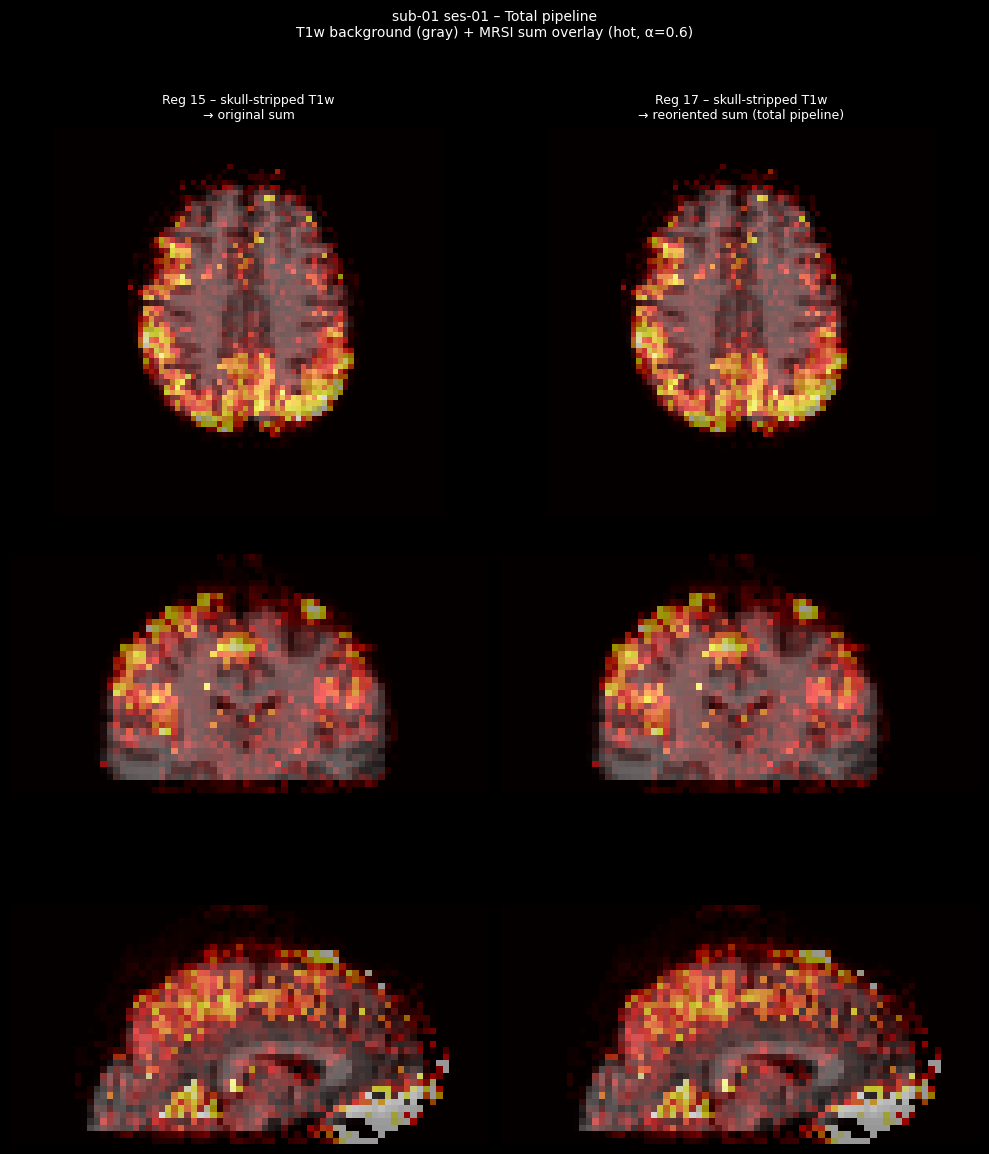

In [ ]:
plot_total_pipeline_comparison(
    sum_orig_img=sum_img,
    t1w_in_sum_orig_img=t1w_brain_in_sum_img,
    sum_ras_img=sum_ras_img,
    t1w_in_sum_ras_img=t1w_brain_in_sum_ras_img,
    subj=SUBJ,
    ses=SES,
)

## 20 – Final transform applied to all metabolites + registration quality metrics

The **Reg-17 transform** (skull-stripped DS T1w → reoriented MRSI sum, water-weighted) is
inverted and applied to every individual metabolite map, warping each one into T1w space
(`antsApplyTransforms [transform.mat, 1]`).

Three quality metrics are computed per metabolite in the **overlap region** (T1w brain > 0 ∩ MRSI signal > 0):

| Metric | Interpretation |
|--------|----------------|
| **Coverage** | Fraction of T1w brain voxels that contain MRSI signal after registration |
| **NCC** | Normalised cross correlation with T1w  higher = better spatial alignment |
| **NMI** | Normalised mutual information  higher = more shared information with T1w |

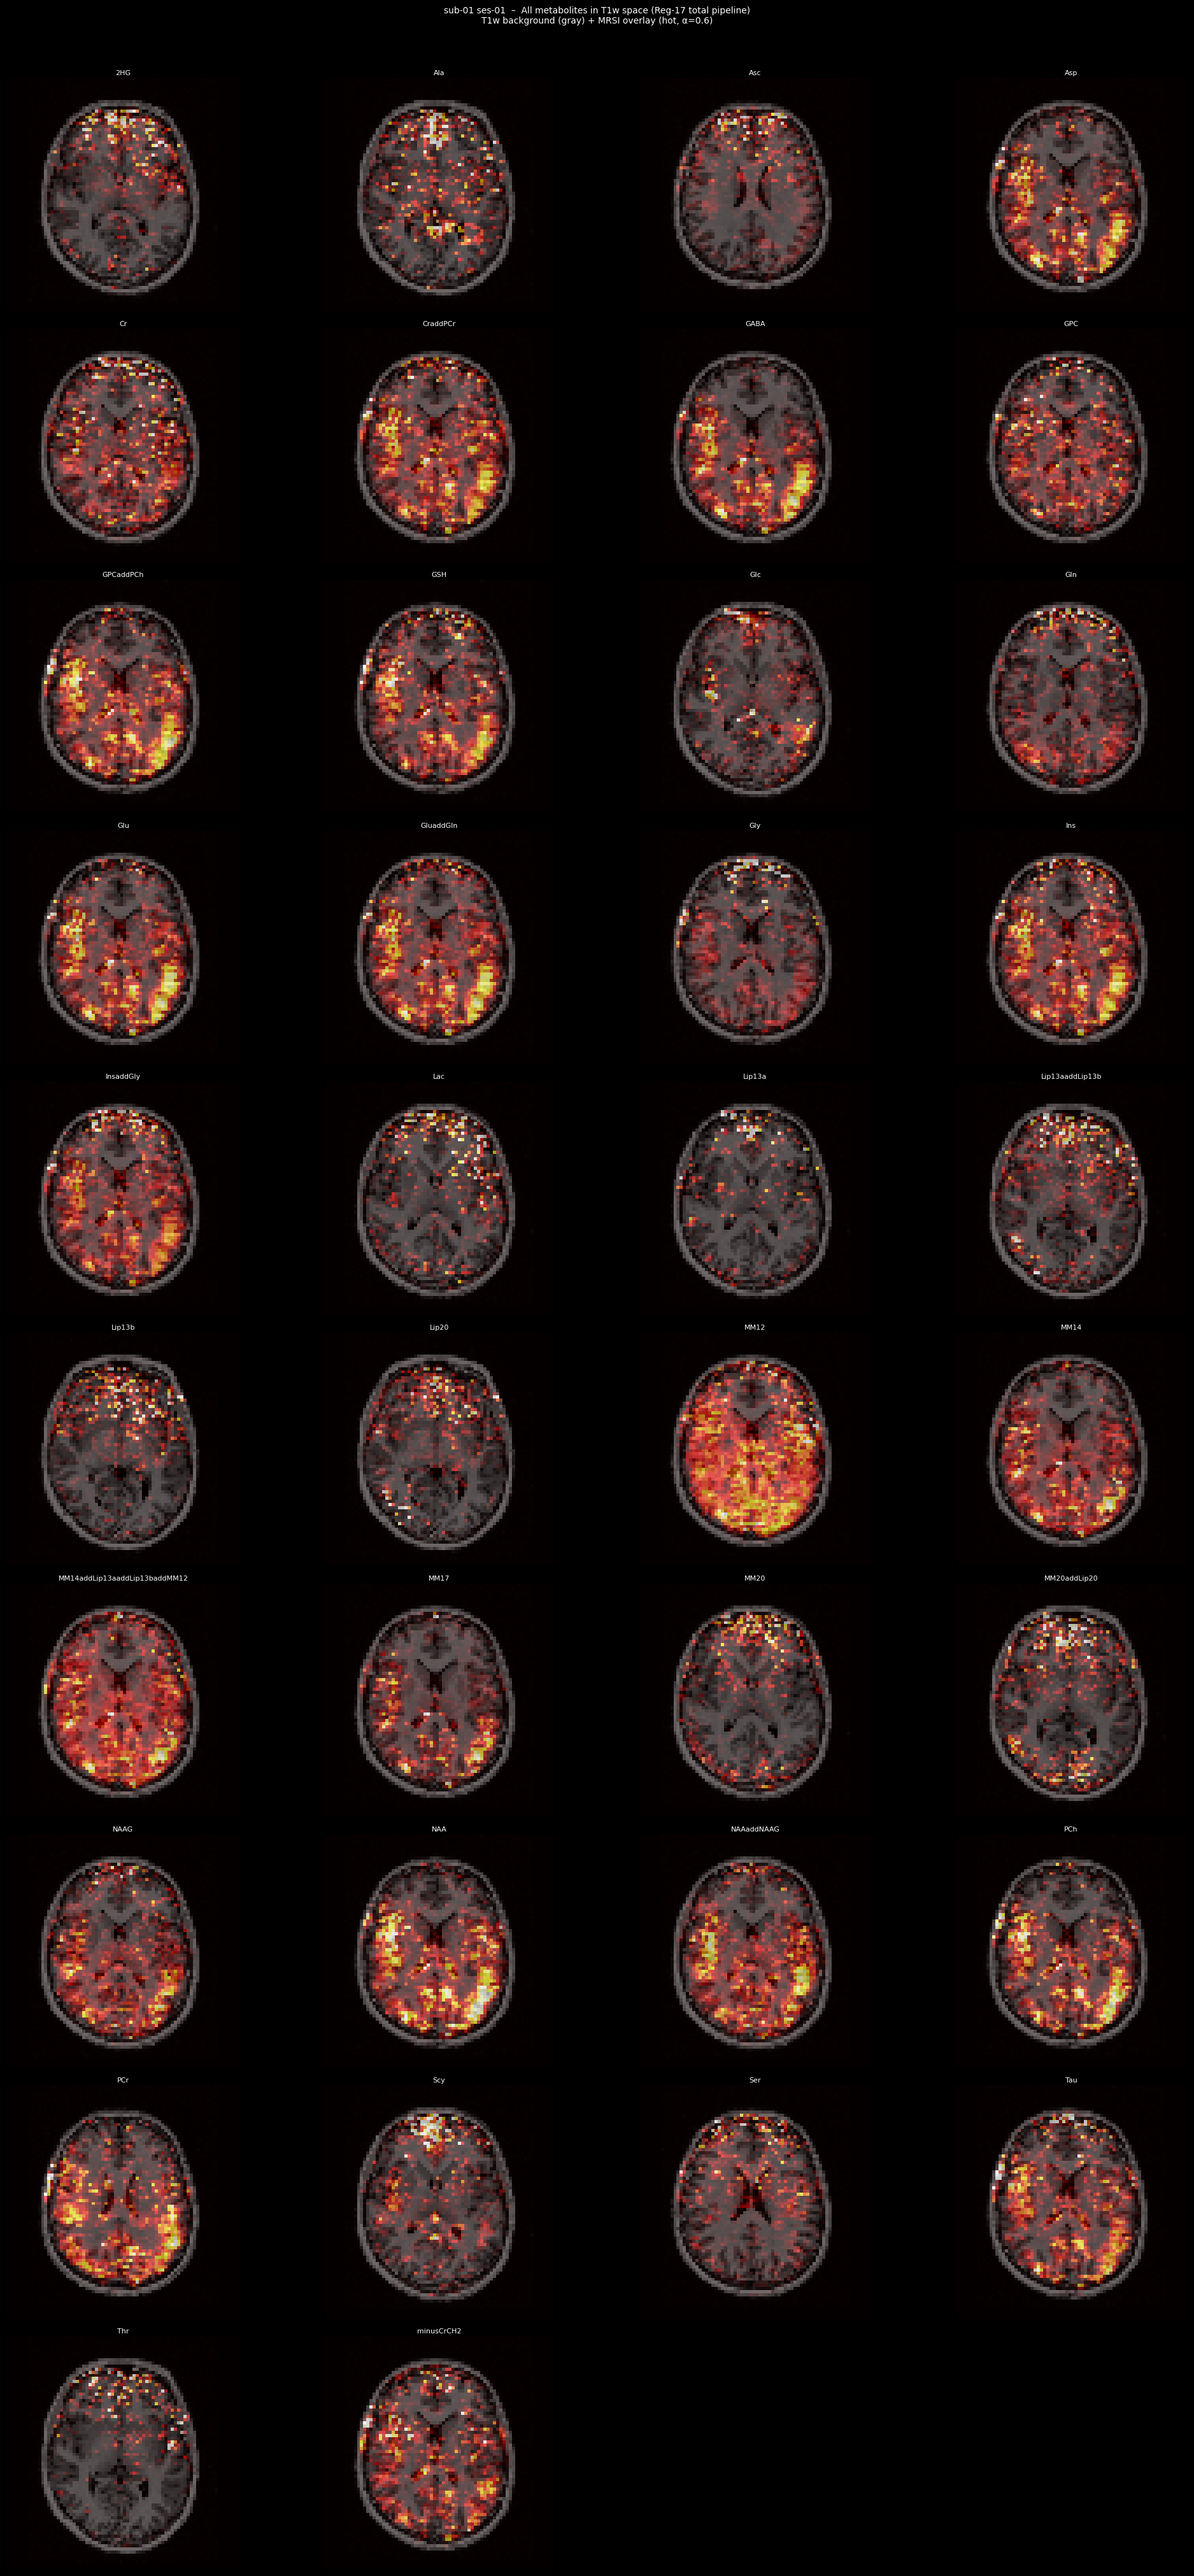

In [ ]:
# Axial mosaic: every metabolite overlaid on the T1w background
plot_final_registration_mosaic(
    t1w_img=t1w_ds_img,
    reg_mrsi_imgs=final_reg_imgs,
    subj=SUBJ,
    ses=SES,
)

/Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/utils.py:2482: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


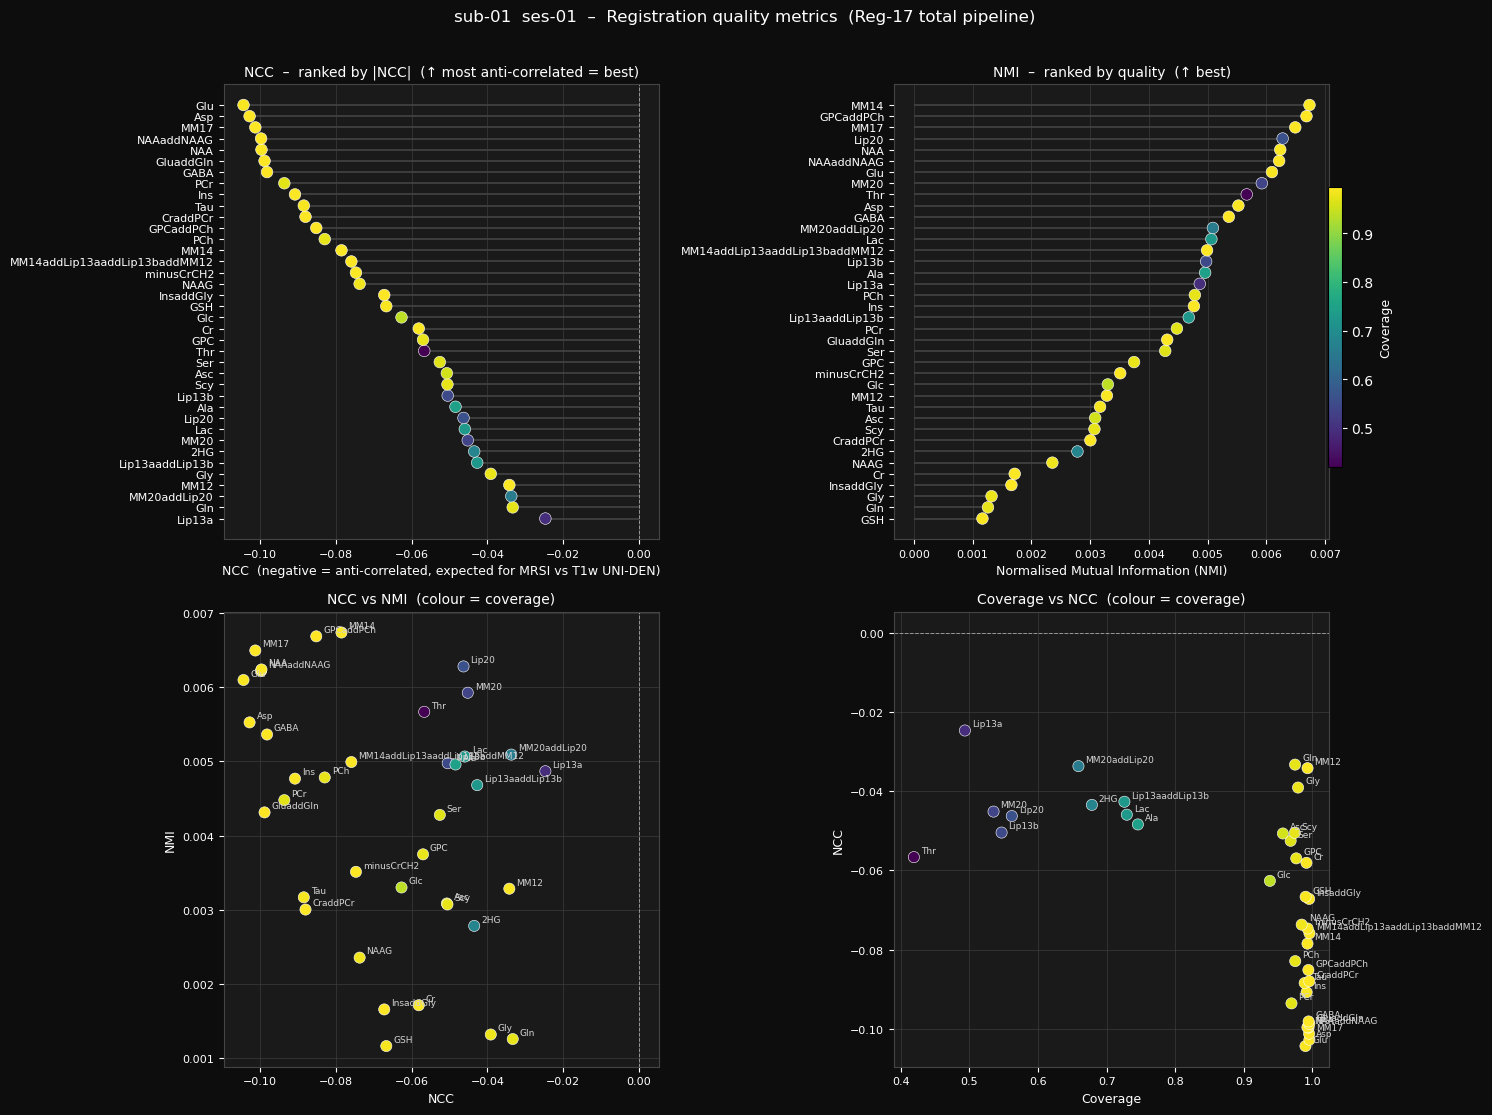


Label                                 Coverage       NCC       NMI
─────────────────────────────────────────────────────────────────
Glu                                      0.990   -0.1043    0.0061
Asp                                      0.995   -0.1027    0.0055
MM17                                     0.995   -0.1012    0.0065
NAAaddNAAG                               0.994   -0.0997    0.0062
NAA                                      0.993   -0.0996    0.0062
GluaddGln                                0.995   -0.0988    0.0043
GABA                                     0.994   -0.0981    0.0054
PCr                                      0.969   -0.0936    0.0045
Ins                                      0.991   -0.0907    0.0048
Tau                                      0.989   -0.0884    0.0032
CraddPCr                                 0.995   -0.0880    0.0030
GPCaddPCh                                0.994   -0.0851    0.0067
PCh                                      0.975   -0.0829    0.

In [ ]:
# Per-metabolite analytical charts: coverage, NCC, NMI
# Recompute if metrics is stale / was overwritten by an earlier cell
if not isinstance(metrics, list) or not metrics:
    if isinstance(final_reg_imgs, dict) and final_reg_imgs:
        print('[metrics] recomputing from final_reg_imgs...')
        metrics = compute_registration_metrics(t1w_ds_brain_img, final_reg_imgs)
    else:
        print('[metrics] final_reg_imgs not available - re-run main.py first.')

plot_registration_metrics(metrics=metrics, subj=SUBJ, ses=SES)


## 21 – Brain tissue segmentation (FSL FAST)

The full-resolution T1w is **first skull-stripped** with FSL BET (`-f 0.3`), then
segmented into three tissue classes using **FSL FAST** — at native T1w resolution
for accurate partial-volume estimation.

| Class | Tissue | FAST PVE map |
|-------|--------|--------------|
| 1 | CSF | `_pve_0.nii.gz` |
| 2 | Grey Matter | `_pve_1.nii.gz` |
| 3 | White Matter | `_pve_2.nii.gz` |

FAST outputs **partial volume estimates (PVE)** per voxel (0–1) and a **hard segmentation** (`_seg.nii.gz`) assigning each voxel to the most probable class.

The figure shows:
- **Top row** — PVE overlay for each tissue class on the skull-stripped full-res T1w background.
- **Bottom row** — hard segmentation (all three classes colour-coded) in ortho view.
- A **volume summary table** (mean PVE and total tissue volume in mL) is printed below.


/Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/utils.py:2647: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


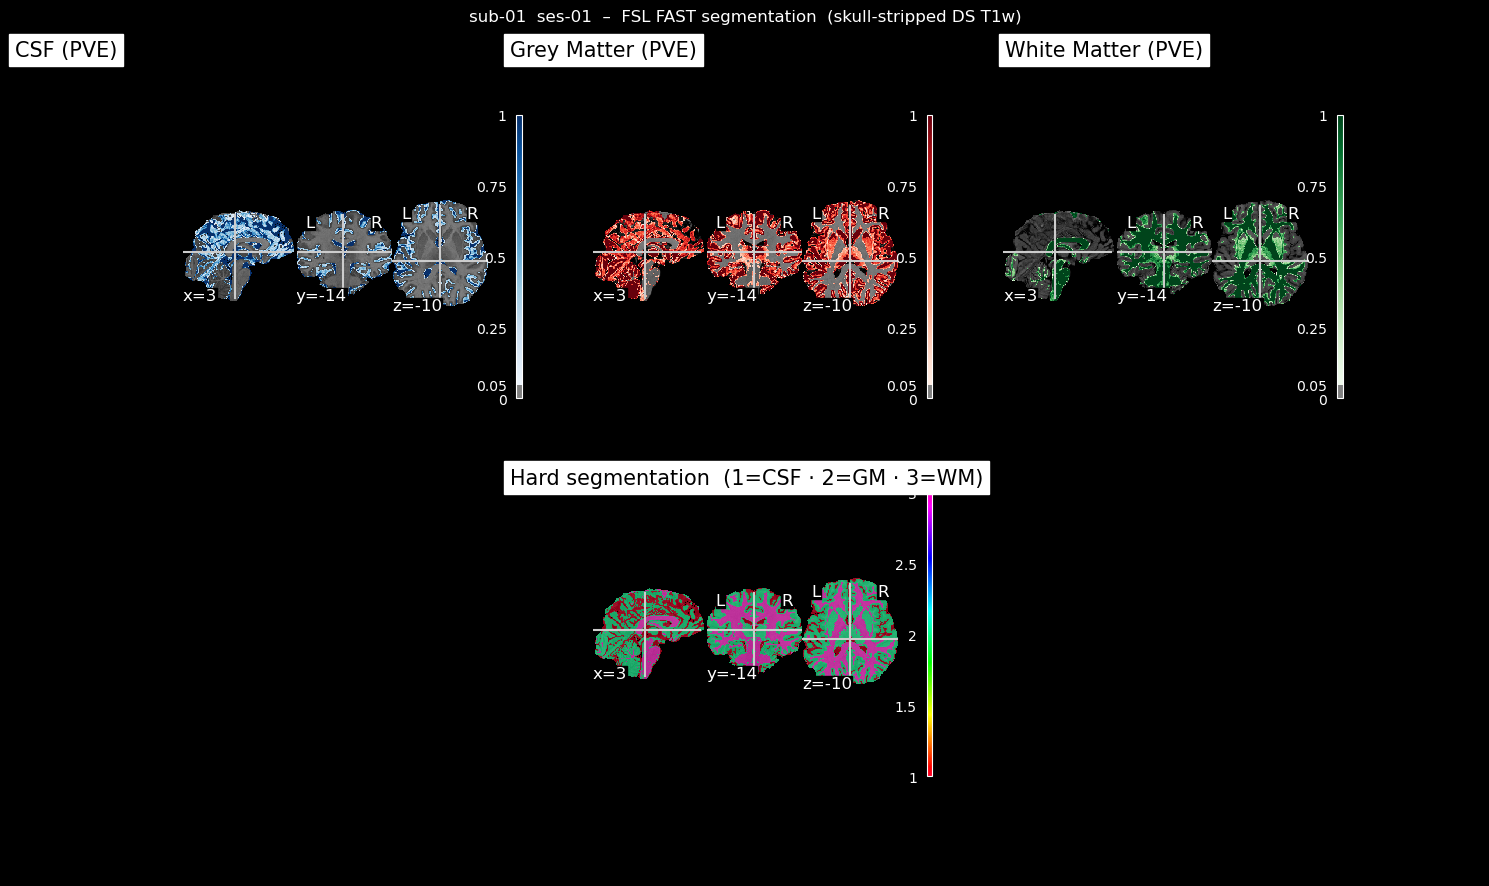


Tissue               Mean PVE   Volume (mL)
────────────────────────────────────────────
  CSF                   0.594        170.9 mL
  Grey Matter           0.718        525.6 mL
  White Matter          0.851        459.4 mL


In [ ]:
plot_segmentation(
    t1w_img=t1w_brain_img,
    seg_imgs=seg_imgs,
    subj=SUBJ,
    ses=SES,
)


## 22 – Atlas-based parcellation (Harvard-Oxford via FLIRT)

The skull-stripped **full-resolution** T1w is registered to the **MNI152 2 mm** standard brain
using **FSL FLIRT** (12 DOF affine, normalised mutual information cost).
The resulting transform is inverted with `convert_xfm` and applied to two
**Harvard-Oxford** max-prob atlases (25% probability threshold, 2 mm resolution):

| Atlas | Regions | File |
|-------|---------|------|
| Cortical | 48 cortical areas (L+R) | `HarvardOxford-cort-maxprob-thr25-2mm` |
| Subcortical | 21 deep grey nuclei (L+R) | `HarvardOxford-sub-maxprob-thr25-2mm` |

The figure shows both parcellations overlaid on the skull-stripped full-res T1w in ortho view,
followed by a **volume table** (label index, region name, volume in mL) for each atlas.

> **Note:** Running registration at native T1w resolution gives the most accurate cortical parcellation.
> For even finer accuracy, re-run `segment_t1w_atlas` with `nonlinear=True`.


/Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/utils.py:2717: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


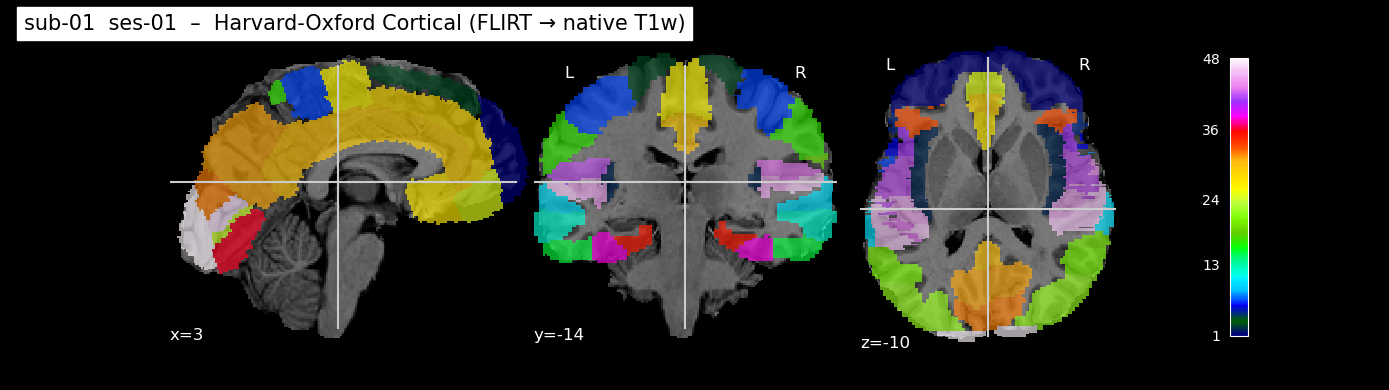

/Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/utils.py:2737: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


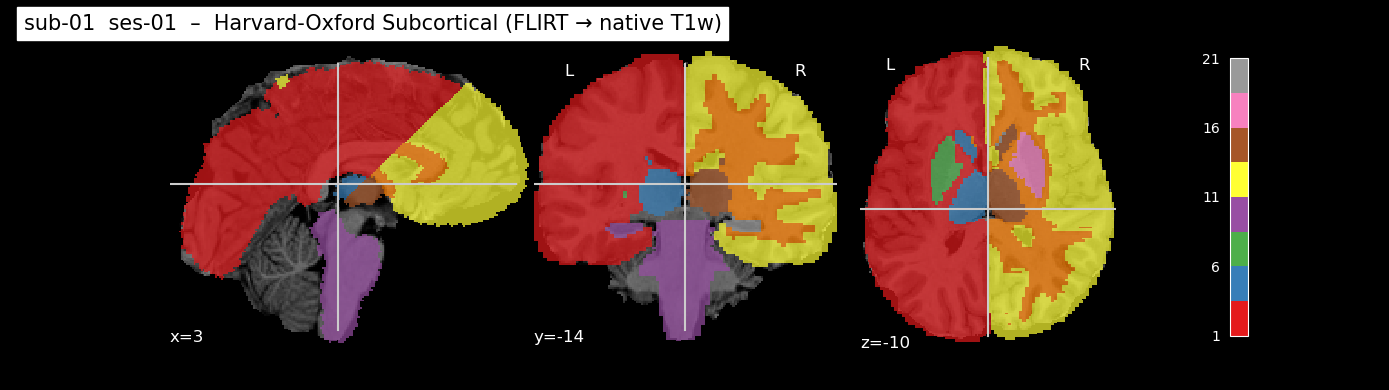


────────────────────────────────────────────────────────────
  Harvard-Oxford Cortical regions  (native T1w space,  thr25, 2 mm)
────────────────────────────────────────────────────────────
   Idx  Region                                         Vol (mL)
────────────────────────────────────────────────────────────
     1  Frontal Pole                                     83.22
     2  Insular Cortex                                   12.61
     3  Superior Frontal Gyrus                           27.48
     4  Middle Frontal Gyrus                             28.77
     5  Inferior Frontal Gyrus, pars triangularis         5.99
     6  Inferior Frontal Gyrus, pars opercularis          7.50
     7  Precentral Gyrus                                 46.39
     8  Temporal Pole                                    25.43
     9  Superior Temporal Gyrus, anterior division        2.83
    10  Superior Temporal Gyrus, posterior division       9.83
    11  Middle Temporal Gyrus, anterior division      

In [ ]:
plot_atlas_segmentation(
    t1w_img=t1w_brain_img,
    atlas_imgs=atlas_imgs,
    subj=SUBJ,
    ses=SES,
)


## 23 – MRSI sum signal vs mask contours

Each axial slice shows the **MRSI metabolite sum** as a greyscale background with three contour overlays — all in native MRSI voxel space:

| Contour | Colour | Meaning |
|---------|--------|---------|
| Sum signal boundary | Yellow | Where the MRSI sum is non-zero (the spectroscopic FOV) |
| Water mask boundary | Blue | Filled water-signal mask (MRSI coverage indicator) |
| BET brain mask boundary | Green | BET skull-strip mask downsampled to MRSI grid |

Slices with large gaps between the yellow FOV boundary and the green brain boundary reveal slabs where MRSI coverage is incomplete.


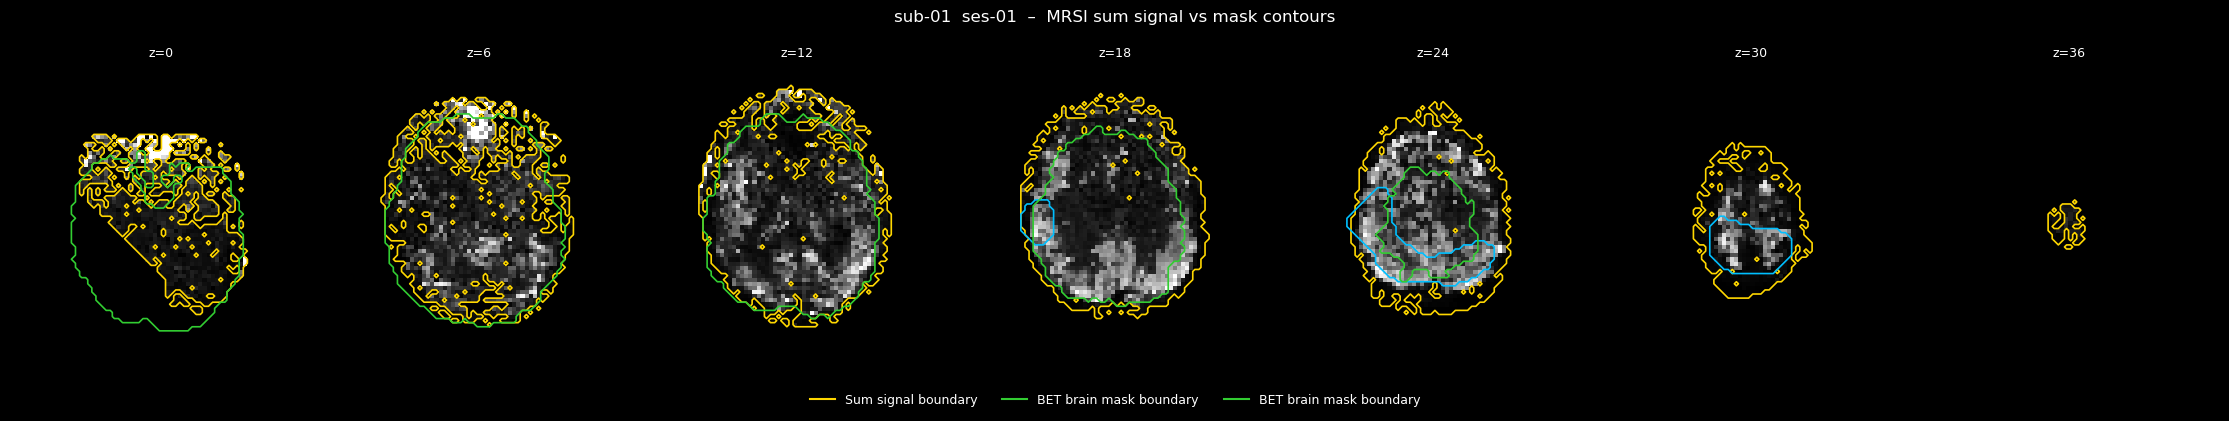

In [ ]:
import nibabel as nib, os

# BET brain mask downsampled to MRSI grid
_bet_mask_img = nib.load(T1W_BRAIN_MASK_DS_PATH) if os.path.exists(T1W_BRAIN_MASK_DS_PATH) else None

plot_mrsi_sum_mask_contours(
    sum_img=sum_img,
    water_mask_img=mask_img,
    bet_mask_img=_bet_mask_img,
    subj=SUBJ,
    ses=SES,
)


## 24 – BET brain mask vs water mask comparison (MRSI grid)

Quantitative and visual comparison of the two spatial masks used in the registration pipeline — both resampled to the **MRSI voxel grid**:

| Mask | Source | Used for |
|------|--------|----------|
| **Water mask** | Filled water-signal threshold | Fixed-image mask in all ANTs registrations |
| **BET brain mask** | FSL BET (`-f 0.5`) downsampled to MRSI res | Moving-image mask in skull-stripped registrations (Regs 14, 15, 17) |

The table reports volumes, intersection, Dice (higher = more similar) and Jaccard.  
The mosaic shows:
- **Row 1** — BET mask (green) on the downsampled T1w background  
- **Row 2** — Water mask (blue) on the same background  
- **Row 3** — BET-only (red) / water-only (blue) / overlap (grey)


────────────────────────────────────────────
  Mask comparison (MRSI grid)
────────────────────────────────────────────
  BET mask volume   :    947.8 mL  ( 36068 vox)
  Water mask volume :     88.7 mL  (  3375 vox)
  Intersection      :     22.9 mL  (   871 vox)
  BET-only voxels   :    924.9 mL  ( 35197 vox)
  Water-only voxels :     65.8 mL  (  2504 vox)
  Dice coefficient  : 0.0442  (1.0 = identical)
  Jaccard index     : 0.0226
  Masks are identical : False
────────────────────────────────────────────

  ACTIVE mask for Reg 18 : sub-01_ses-01_acq-MRSIres_desc-BrainMask_T1w.nii.gz


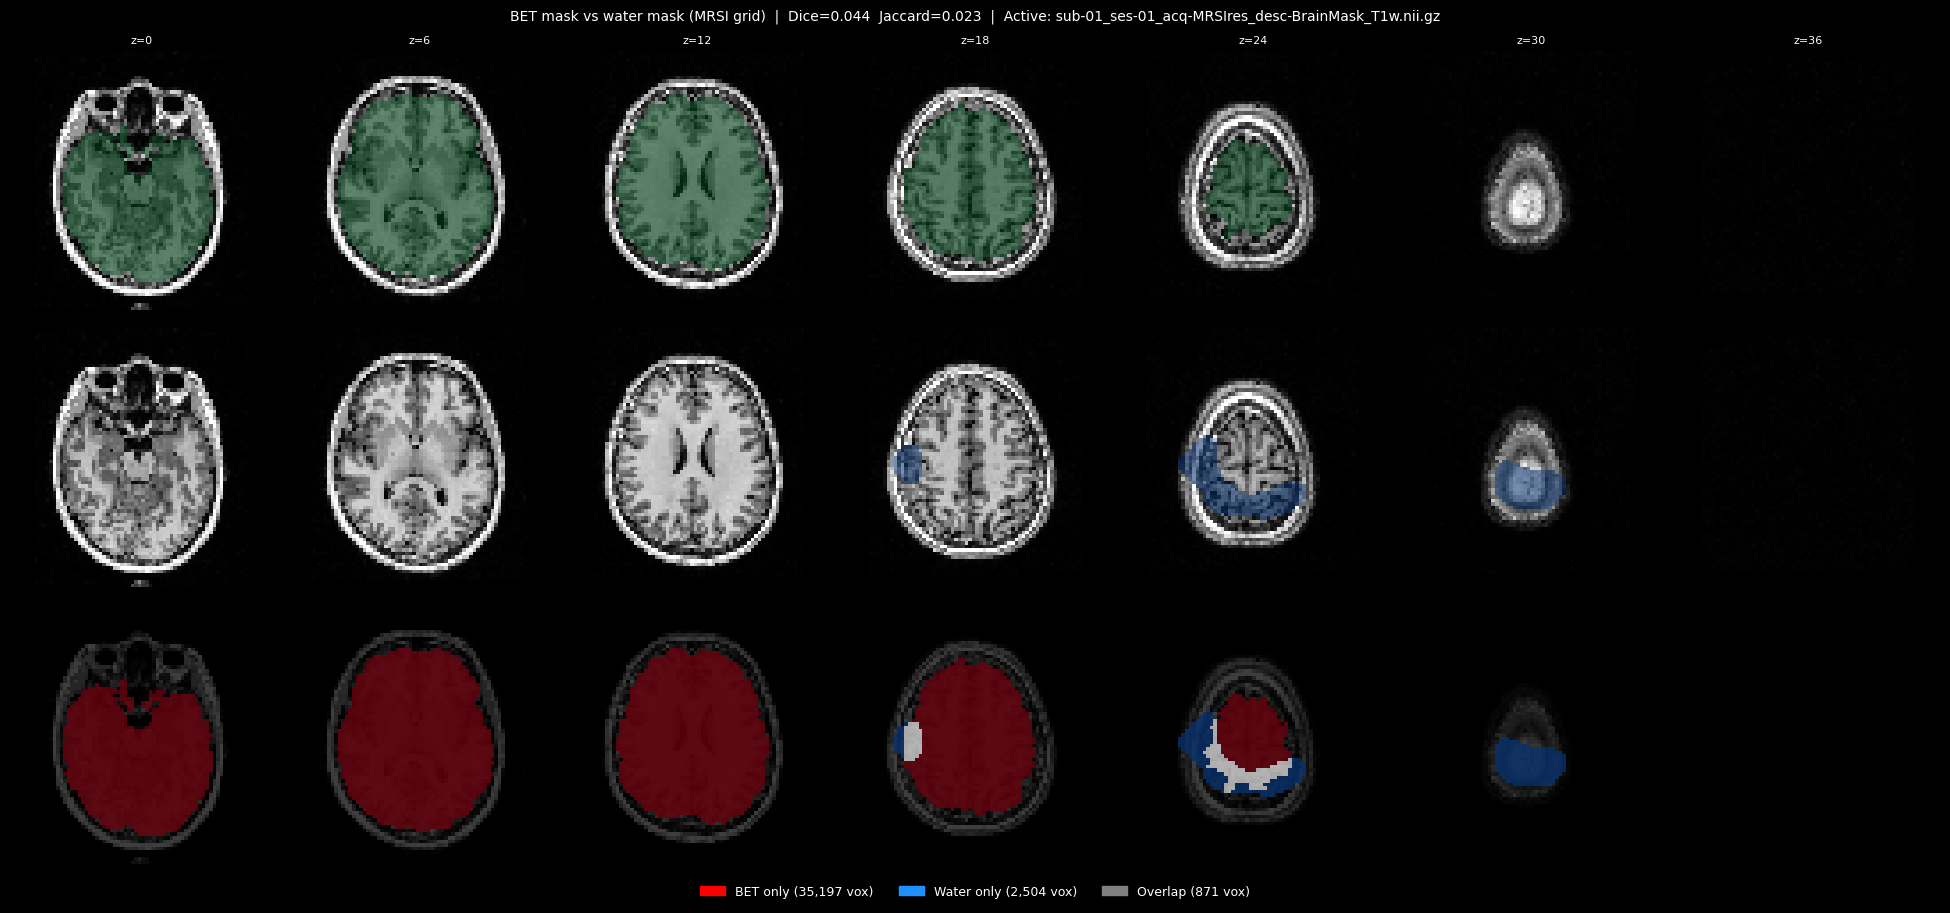

In [ ]:
import nibabel as nib, os

_bet_mask_img = nib.load(T1W_BRAIN_MASK_DS_PATH) if os.path.exists(T1W_BRAIN_MASK_DS_PATH) else None

if _bet_mask_img is not None:
    plot_bet_vs_water_mask(
        bet_mask_img=_bet_mask_img,
        water_mask_img=mask_img,
        t1w_ds_img=t1w_ds_img,
        subj=SUBJ,
        ses=SES,
        active_mask_name=T1W_BRAIN_MASK_DS_NAME,
    )
else:
    print("BET mask not available – run main.py first (skull_strip_t1w).")
